# 07 — Latent Manipulation
**Dự án:** Latent Manipulation of Brain MRI using Volume-Preserving GANs

**Mục tiêu:** Dùng model tốt nhất từ file 03 và 06 để simulate aging:
- Lấy 1 ảnh não gốc
- Giữ nguyên giải phẫu
- Thay đổi tuổi trong latent space → sinh ra não ở các mốc tuổi khác nhau

**Output:**
```
latent_manipulation/
├── 2d_aging_simulation.png   ← kết quả GAN 2D
└── 3d_aging_simulation.png   ← kết quả GAN 3D (axial slice)
```

## Bước 1: Cấu hình

In [3]:
import os, json

# ==== MODEL 2D ====
COMPARE_2D_JSON   = '/kaggle/input/datasets/minhbodoi/compare-2d/comparison_result.json'
MODEL_2D_NORM     = '/kaggle/input/datasets/cminhnguyndsdsds/conditional-gan2d-normalized/best_model.pth'
MODEL_2D_UNNORM   = '/kaggle/input/datasets/dyio147/conditional-gan2d-unnormalized/best_model.pth'

# ==== MODEL 3D ====
COMPARE_3D_JSON   = '/kaggle/input/datasets/minhbodoi/compare-3d/comparison_result.json'
MODEL_3D_NORM     = '/kaggle/input/datasets/cminhnguyndsdsds/conditional-gan3d-normalized/best_model.pth'
MODEL_3D_UNNORM   = '/kaggle/input/datasets/dyio147/conditional-gan3d-unnormalized/best_model.pth'

# ==== DATA ====
DATA_2D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/normalized'
DATA_2D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/unnormalized'
DATA_3D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/normalized'
DATA_3D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/unnormalized'
LABELS_2D_CSV      = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/preprocessing_log.csv'
LABELS_3D_CSV      = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/preprocessing_log.csv'

OUTPUT_DIR = '/kaggle/working/latent_manipulation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_AGES = [20, 30, 40, 50, 60, 70, 80]
LATENT_DIM  = 256
N_SAMPLES   = 300  # số subject dùng để fit direction vector

with open(COMPARE_2D_JSON) as f: winner_2d = json.load(f)['winner']
with open(COMPARE_3D_JSON) as f: winner_3d = json.load(f)['winner']

MODEL_2D_PATH = MODEL_2D_NORM    if winner_2d == 'normalized' else MODEL_2D_UNNORM
MODEL_3D_PATH = MODEL_3D_NORM    if winner_3d == 'normalized' else MODEL_3D_UNNORM
DATA_2D_DIR   = DATA_2D_NORM_DIR if winner_2d == 'normalized' else DATA_2D_UNNORM_DIR
DATA_3D_DIR   = DATA_3D_NORM_DIR if winner_3d == 'normalized' else DATA_3D_UNNORM_DIR

print(f'Winner 2D: {winner_2d}')
print(f'Winner 3D: {winner_3d}')


Winner 2D: normalized
Winner 3D: unnormalized


## Bước 2: Import thư viện

In [4]:
!pip install nibabel -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from PIL import Image
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Bước 3: Định nghĩa kiến trúc model

In [5]:
class AgeEmbedding(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
    def forward(self, age):
        return self.net(age.unsqueeze(-1))


# ===== 2D =====
class UNetBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm2d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator2D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 512)
        self.e1 = UNetBlock2D(1,   64,  down=True, use_bn=False)
        self.e2 = UNetBlock2D(64,  128, down=True)
        self.e3 = UNetBlock2D(128, 256, down=True)
        self.e4 = UNetBlock2D(256, 512, down=True)
        self.e5 = UNetBlock2D(512, 512, down=True)
        self.e6 = UNetBlock2D(512, 512, down=True)
        self.e7 = UNetBlock2D(512, 512, down=True)
        self.e8 = UNetBlock2D(512, 512, down=True, use_bn=False)
        self.d1 = UNetBlock2D(512,  512, down=False, dropout=True)
        self.d2 = UNetBlock2D(1024, 512, down=False, dropout=True)
        self.d3 = UNetBlock2D(1024, 512, down=False, dropout=True)
        self.d4 = UNetBlock2D(1024, 512, down=False)
        self.d5 = UNetBlock2D(1024, 256, down=False)
        self.d6 = UNetBlock2D(512,  128, down=False)
        self.d7 = UNetBlock2D(256,  64,  down=False)
        self.out = nn.Sequential(nn.ConvTranspose2d(128, 1, 4, 2, 1), nn.Tanh())

    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        z = e8 + self.age_proj(self.age_embed(age)).view(-1, 512, 1, 1)
        d1=self.d1(z)
        d2=self.d2(torch.cat([d1,e7],dim=1))
        d3=self.d3(torch.cat([d2,e6],dim=1))
        d4=self.d4(torch.cat([d3,e5],dim=1))
        d5=self.d5(torch.cat([d4,e4],dim=1))
        d6=self.d6(torch.cat([d5,e3],dim=1))
        d7=self.d7(torch.cat([d6,e2],dim=1))
        return self.out(torch.cat([d7,e1],dim=1))

    def encode(self, x, age):
        """Trả về bottleneck z — dùng để examine/manipulate latent space."""
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        z = e8 + self.age_proj(self.age_embed(age)).view(-1, 512, 1, 1)
        return z.squeeze(-1).squeeze(-1)  # (B, 512)


# ===== 3D =====
class UNetBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv3d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose3d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm3d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator3D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 256)
        self.e1 = UNetBlock3D(1,   32,  down=True, use_bn=False)
        self.e2 = UNetBlock3D(32,  64,  down=True)
        self.e3 = UNetBlock3D(64,  128, down=True)
        self.e4 = UNetBlock3D(128, 256, down=True, use_bn=False)
        self.d1 = UNetBlock3D(256, 128, down=False, dropout=True)
        self.d2 = UNetBlock3D(256, 64,  down=False)
        self.d3 = UNetBlock3D(128, 32,  down=False)
        self.out = nn.Sequential(nn.ConvTranspose3d(64, 1, 4, 2, 1), nn.Tanh())

    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        z = e4 + self.age_proj(self.age_embed(age)).view(-1, 256, 1, 1, 1)
        d1=self.d1(z)
        d2=self.d2(torch.cat([d1,e3],dim=1))
        d3=self.d3(torch.cat([d2,e2],dim=1))
        return self.out(torch.cat([d3,e1],dim=1))

    def encode(self, x, age):
        """Trả về bottleneck z 3D."""
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        z = e4 + self.age_proj(self.age_embed(age)).view(-1, 256, 1, 1, 1)
        return z.mean(dim=[-3,-2,-1])  # (B, 256)


print('Kiến trúc model định nghĩa xong!')

# ── StyleGAN classes ──────────────────────────────────────────
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim=256, w_dim=512, n_layers=4):
        super().__init__()
        layers = [AgeEmbedding(latent_dim), nn.ReLU()]
        in_dim = latent_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, w_dim), nn.ReLU()]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, w_dim)
    def forward(self, age): return self.out(self.net(age))

class AdaIN2D(nn.Module):
    def __init__(self, channels, w_dim=512):
        super().__init__()
        self.norm  = nn.InstanceNorm2d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)
    def forward(self, x, w):
        style = self.style(w).unsqueeze(-1).unsqueeze(-1)
        scale, shift = style.chunk(2, dim=1)
        return scale * self.norm(x) + shift

class Generator2D_StyleGAN(nn.Module):
    def __init__(self, latent_dim=256, w_dim=512):
        super().__init__()
        self.mapping = MappingNetwork(latent_dim, w_dim)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=nn.Sequential(nn.ConvTranspose2d(512,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d2=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d3=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d4=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.ReLU())
        self.d5=nn.Sequential(nn.ConvTranspose2d(1024,256,4,2,1,bias=False),nn.ReLU())
        self.d6=nn.Sequential(nn.ConvTranspose2d(512,128,4,2,1,bias=False),nn.ReLU())
        self.d7=nn.Sequential(nn.ConvTranspose2d(256,64,4,2,1,bias=False),nn.ReLU())
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
        self.adain1=AdaIN2D(512,w_dim); self.adain2=AdaIN2D(512,w_dim)
        self.adain3=AdaIN2D(512,w_dim); self.adain4=AdaIN2D(512,w_dim)
        self.adain5=AdaIN2D(256,w_dim); self.adain6=AdaIN2D(128,w_dim)
        self.adain7=AdaIN2D(64,w_dim)
    def forward(self, x, age):
        w=self.mapping(age)
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        d1=self.adain1(self.d1(e8),w); d2=self.adain2(self.d2(torch.cat([d1,e7],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e6],1)),w); d4=self.adain4(self.d4(torch.cat([d3,e5],1)),w)
        d5=self.adain5(self.d5(torch.cat([d4,e4],1)),w); d6=self.adain6(self.d6(torch.cat([d5,e3],1)),w)
        d7=self.adain7(self.d7(torch.cat([d6,e2],1)),w)
        return self.out(torch.cat([d7,e1],1))
    def encode(self, x, age): return self.mapping(age)
    def decode_from_w(self, x, w):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        d1=self.adain1(self.d1(e8),w); d2=self.adain2(self.d2(torch.cat([d1,e7],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e6],1)),w); d4=self.adain4(self.d4(torch.cat([d3,e5],1)),w)
        d5=self.adain5(self.d5(torch.cat([d4,e4],1)),w); d6=self.adain6(self.d6(torch.cat([d5,e3],1)),w)
        d7=self.adain7(self.d7(torch.cat([d6,e2],1)),w)
        return self.out(torch.cat([d7,e1],1))

class MappingNetwork3D(nn.Module):
    def __init__(self, latent_dim=256, w_dim=256, n_layers=4):
        super().__init__()
        layers = [AgeEmbedding(latent_dim), nn.ReLU()]
        in_dim = latent_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, w_dim), nn.ReLU()]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, w_dim)
    def forward(self, age): return self.out(self.net(age))

class AdaIN3D(nn.Module):
    def __init__(self, channels, w_dim=256):
        super().__init__()
        self.norm  = nn.InstanceNorm3d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)
    def forward(self, x, w):
        style = self.style(w).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        scale, shift = style.chunk(2, dim=1)
        return scale * self.norm(x) + shift

class Generator3D_StyleGAN(nn.Module):
    def __init__(self, latent_dim=256, w_dim=256):
        super().__init__()
        self.mapping = MappingNetwork3D(latent_dim, w_dim)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=nn.Sequential(nn.ConvTranspose3d(256,128,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d2=nn.Sequential(nn.ConvTranspose3d(256,64,4,2,1,bias=False),nn.ReLU())
        self.d3=nn.Sequential(nn.ConvTranspose3d(128,32,4,2,1,bias=False),nn.ReLU())
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
        self.adain1=AdaIN3D(128,w_dim); self.adain2=AdaIN3D(64,w_dim); self.adain3=AdaIN3D(32,w_dim)
    def forward(self, x, age):
        w=self.mapping(age)
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        d1=self.adain1(self.d1(e4),w); d2=self.adain2(self.d2(torch.cat([d1,e3],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e2],1)),w)
        return self.out(torch.cat([d3,e1],1))
    def encode(self, x, age): return self.mapping(age)
    def decode_from_w(self, x, w):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        sp = e4.shape[2:]
        z_s = w.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1).expand(-1,-1,*sp)
        d1=self.adain1(self.d1(z_s),w); d2=self.adain2(self.d2(torch.cat([d1,e3],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e2],1)),w)
        return self.out(torch.cat([d3,e1],1))


# ── Kiến trúc Concat (age_fuse) ───────────────────────────────
class Generator2D_Concat(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 512)
        self.age_fuse  = nn.Conv2d(1024, 512, 1)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=UNetBlock2D(512,512,down=False,dropout=True); self.d2=UNetBlock2D(1024,512,down=False,dropout=True)
        self.d3=UNetBlock2D(1024,512,down=False,dropout=True); self.d4=UNetBlock2D(1024,512,down=False)
        self.d5=UNetBlock2D(1024,256,down=False); self.d6=UNetBlock2D(512,128,down=False)
        self.d7=UNetBlock2D(256,64,down=False)
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,512,1,1).expand_as(e8)
        z=self.age_fuse(torch.cat([e8,age_feat],dim=1))
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e7],1)); d3=self.d3(torch.cat([d2,e6],1))
        d4=self.d4(torch.cat([d3,e5],1)); d5=self.d5(torch.cat([d4,e4],1))
        d6=self.d6(torch.cat([d5,e3],1)); d7=self.d7(torch.cat([d6,e2],1))
        return self.out(torch.cat([d7,e1],1))
    def encode(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,512,1,1).expand_as(e8)
        return self.age_fuse(torch.cat([e8,age_feat],dim=1)).squeeze(-1).squeeze(-1).mean(dim=[-2,-1]) if e8.shape[-1]>1 else self.age_fuse(torch.cat([e8,age_feat],dim=1)).squeeze(-1).squeeze(-1)

class Generator3D_Concat(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 256)
        self.age_fuse  = nn.Conv3d(512, 256, 1)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=UNetBlock3D(256,128,down=False,dropout=True)
        self.d2=UNetBlock3D(256,64,down=False); self.d3=UNetBlock3D(128,32,down=False)
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,256,1,1,1).expand_as(e4)
        z=self.age_fuse(torch.cat([e4,age_feat],dim=1))
        d1=self.d1(z); d2=self.d2(torch.cat([d1,e3],1)); d3=self.d3(torch.cat([d2,e2],1))
        return self.out(torch.cat([d3,e1],1))
    def encode(self, x, age):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        age_feat=self.age_proj(self.age_embed(age)).view(-1,256,1,1,1).expand_as(e4)
        return self.age_fuse(torch.cat([e4,age_feat],dim=1)).mean(dim=[-3,-2,-1])


Kiến trúc model định nghĩa xong!


## Bước 4: Load model tốt nhất

In [6]:
def auto_load_2d(path):
    ckpt = torch.load(path, map_location=DEVICE)
    keys = list(ckpt['G_state'].keys())
    if any('mapping' in k for k in keys):
        G = Generator2D_StyleGAN(LATENT_DIM).to(DEVICE)
    elif any('age_fuse' in k for k in keys):
        G = Generator2D_Concat(LATENT_DIM).to(DEVICE)
    else:
        G = Generator2D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval()
    return G, ckpt

def auto_load_3d(path):
    ckpt = torch.load(path, map_location=DEVICE)
    keys = list(ckpt['G_state'].keys())
    if any('mapping' in k for k in keys):
        G = Generator3D_StyleGAN(LATENT_DIM).to(DEVICE)
    elif any('age_fuse' in k for k in keys):
        G = Generator3D_Concat(LATENT_DIM).to(DEVICE)
    else:
        G = Generator3D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval()
    return G, ckpt

G2D, ckpt_2d = auto_load_2d(MODEL_2D_PATH)
G3D, ckpt_3d = auto_load_3d(MODEL_3D_PATH)

print(f'GAN 2D ({winner_2d}) loaded | best_val_SSIM: {ckpt_2d.get("best_val_ssim",-1):.4f}')
print(f'GAN 3D ({winner_3d}) loaded | best_val_SSIM: {ckpt_3d.get("best_val_ssim",-1):.4f}')


GAN 2D (normalized) loaded | best_val_SSIM: 0.9778
GAN 3D (unnormalized) loaded | best_val_SSIM: 0.9805


## Bước 5: Latent Manipulation — GAN 2D

Đang extract z 2D để tìm age direction...
Age direction 2D found! norm=0.8930


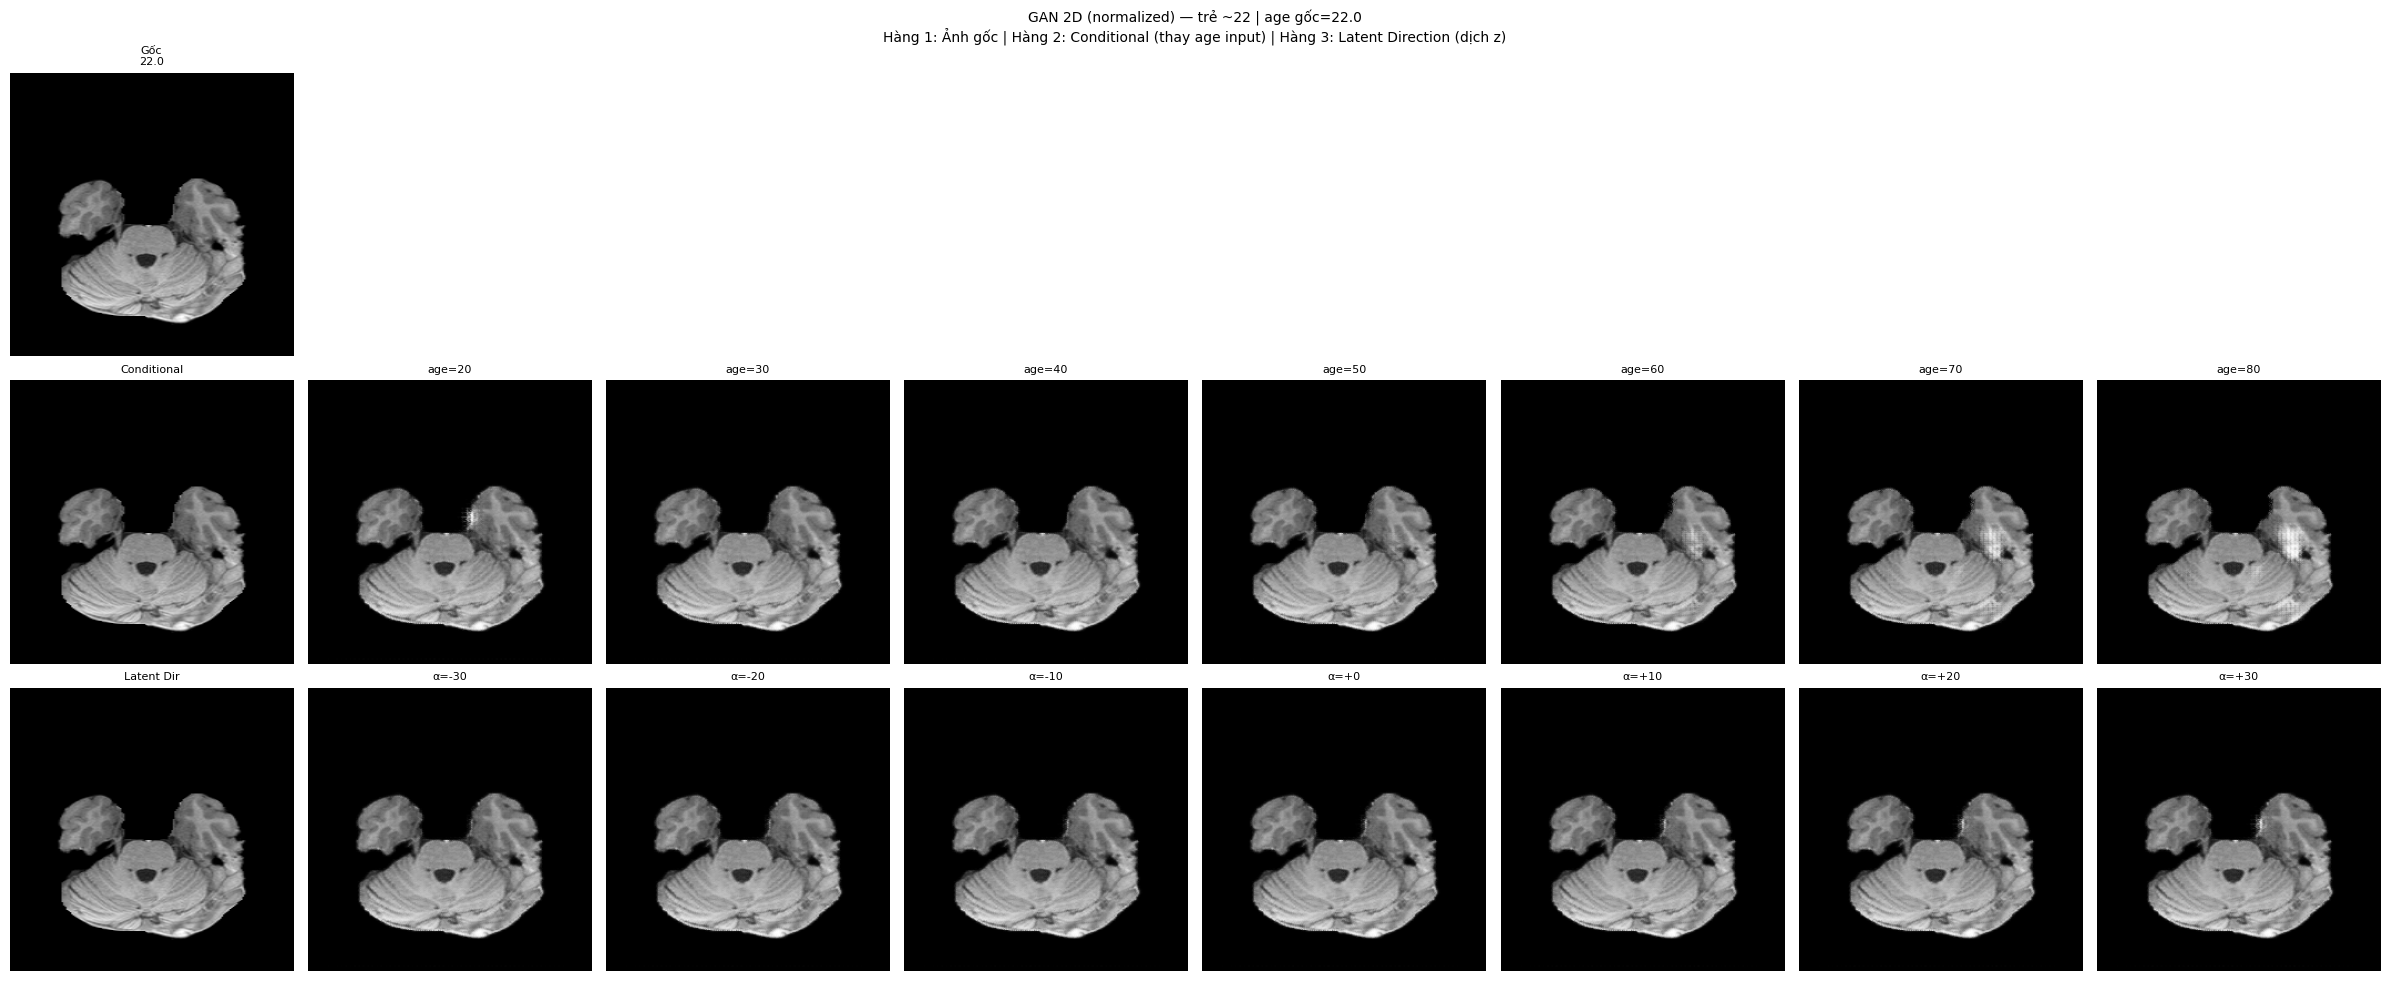

trẻ ~22 (age=22.0) xong!


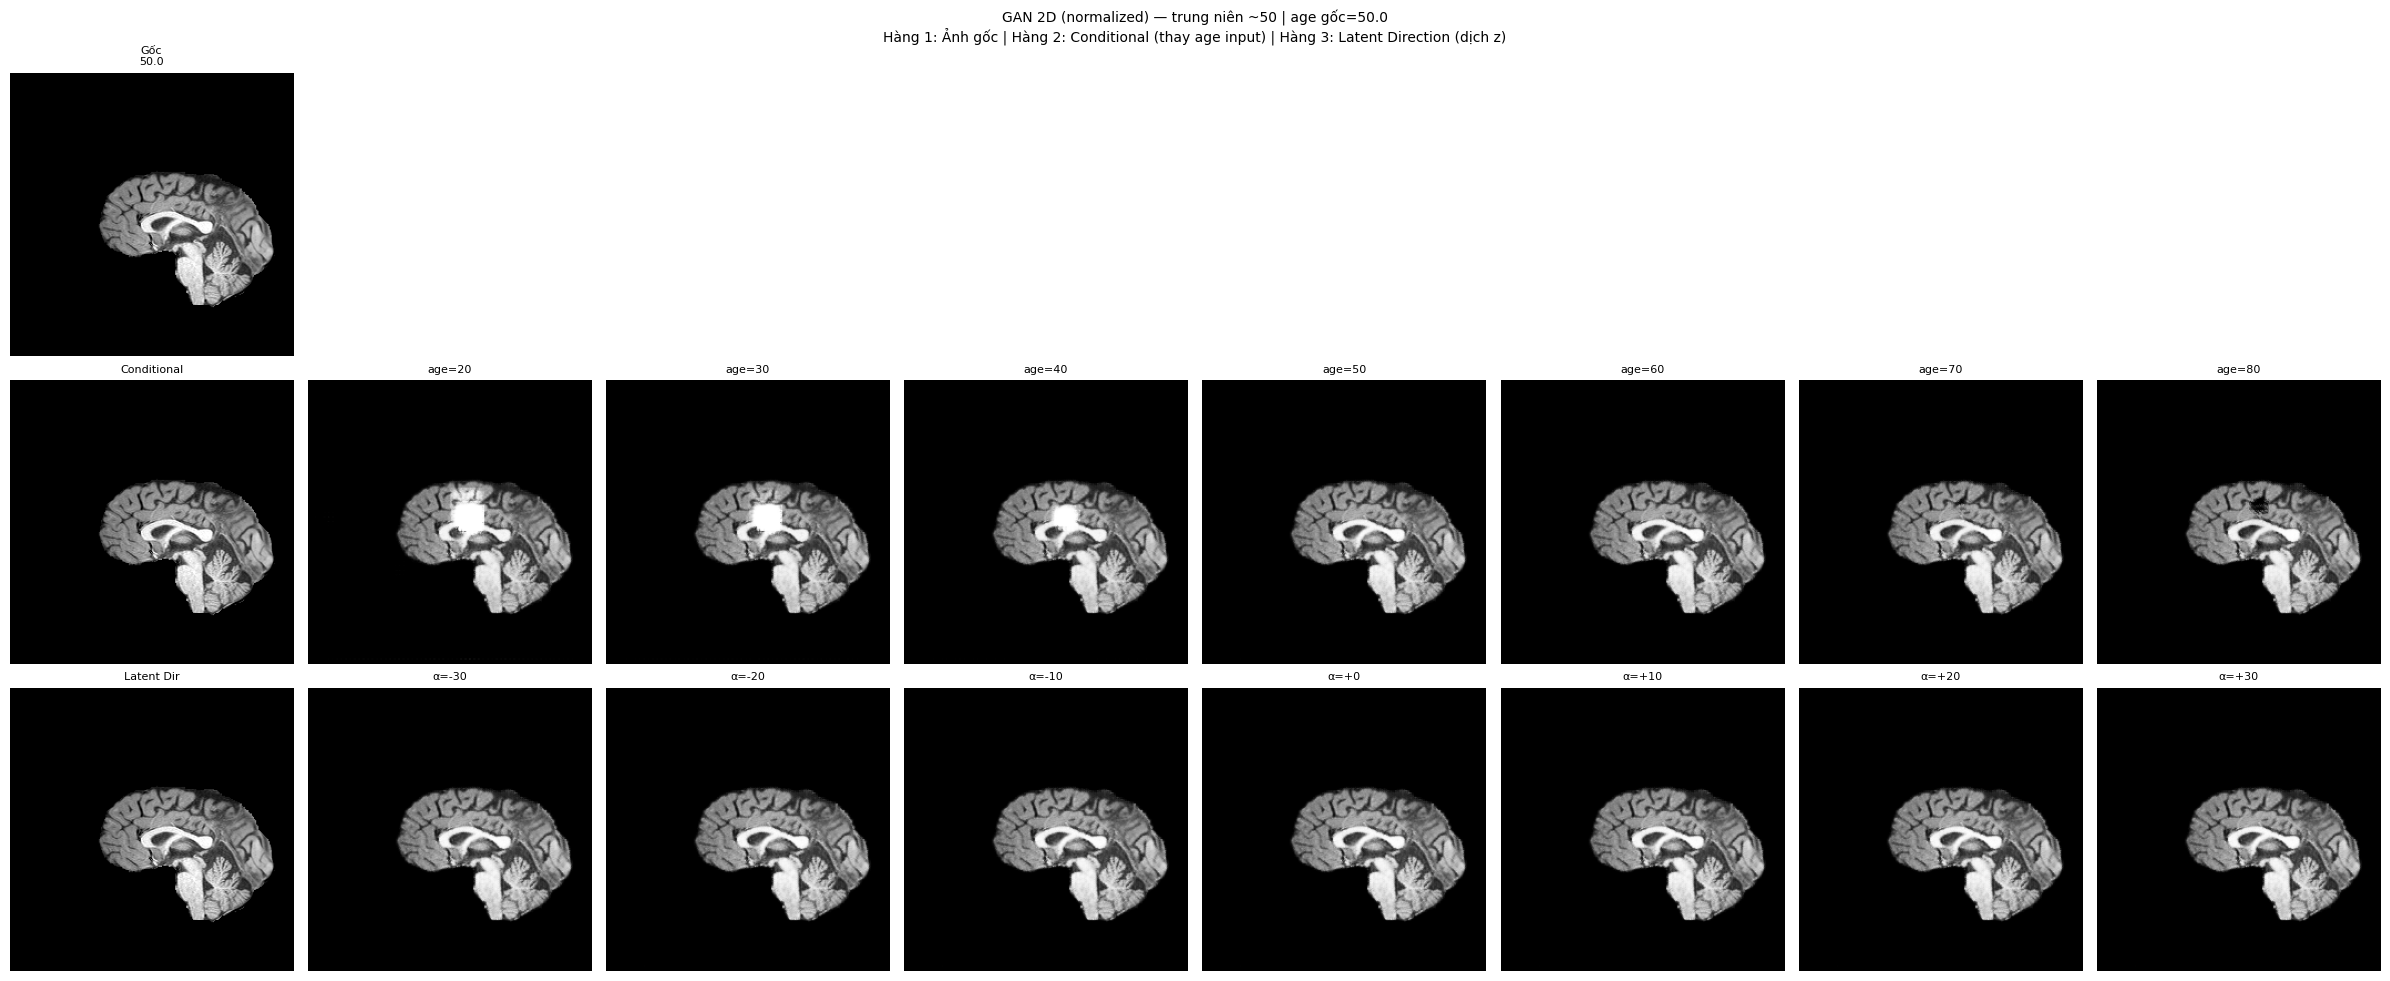

trung niên ~50 (age=50.0) xong!


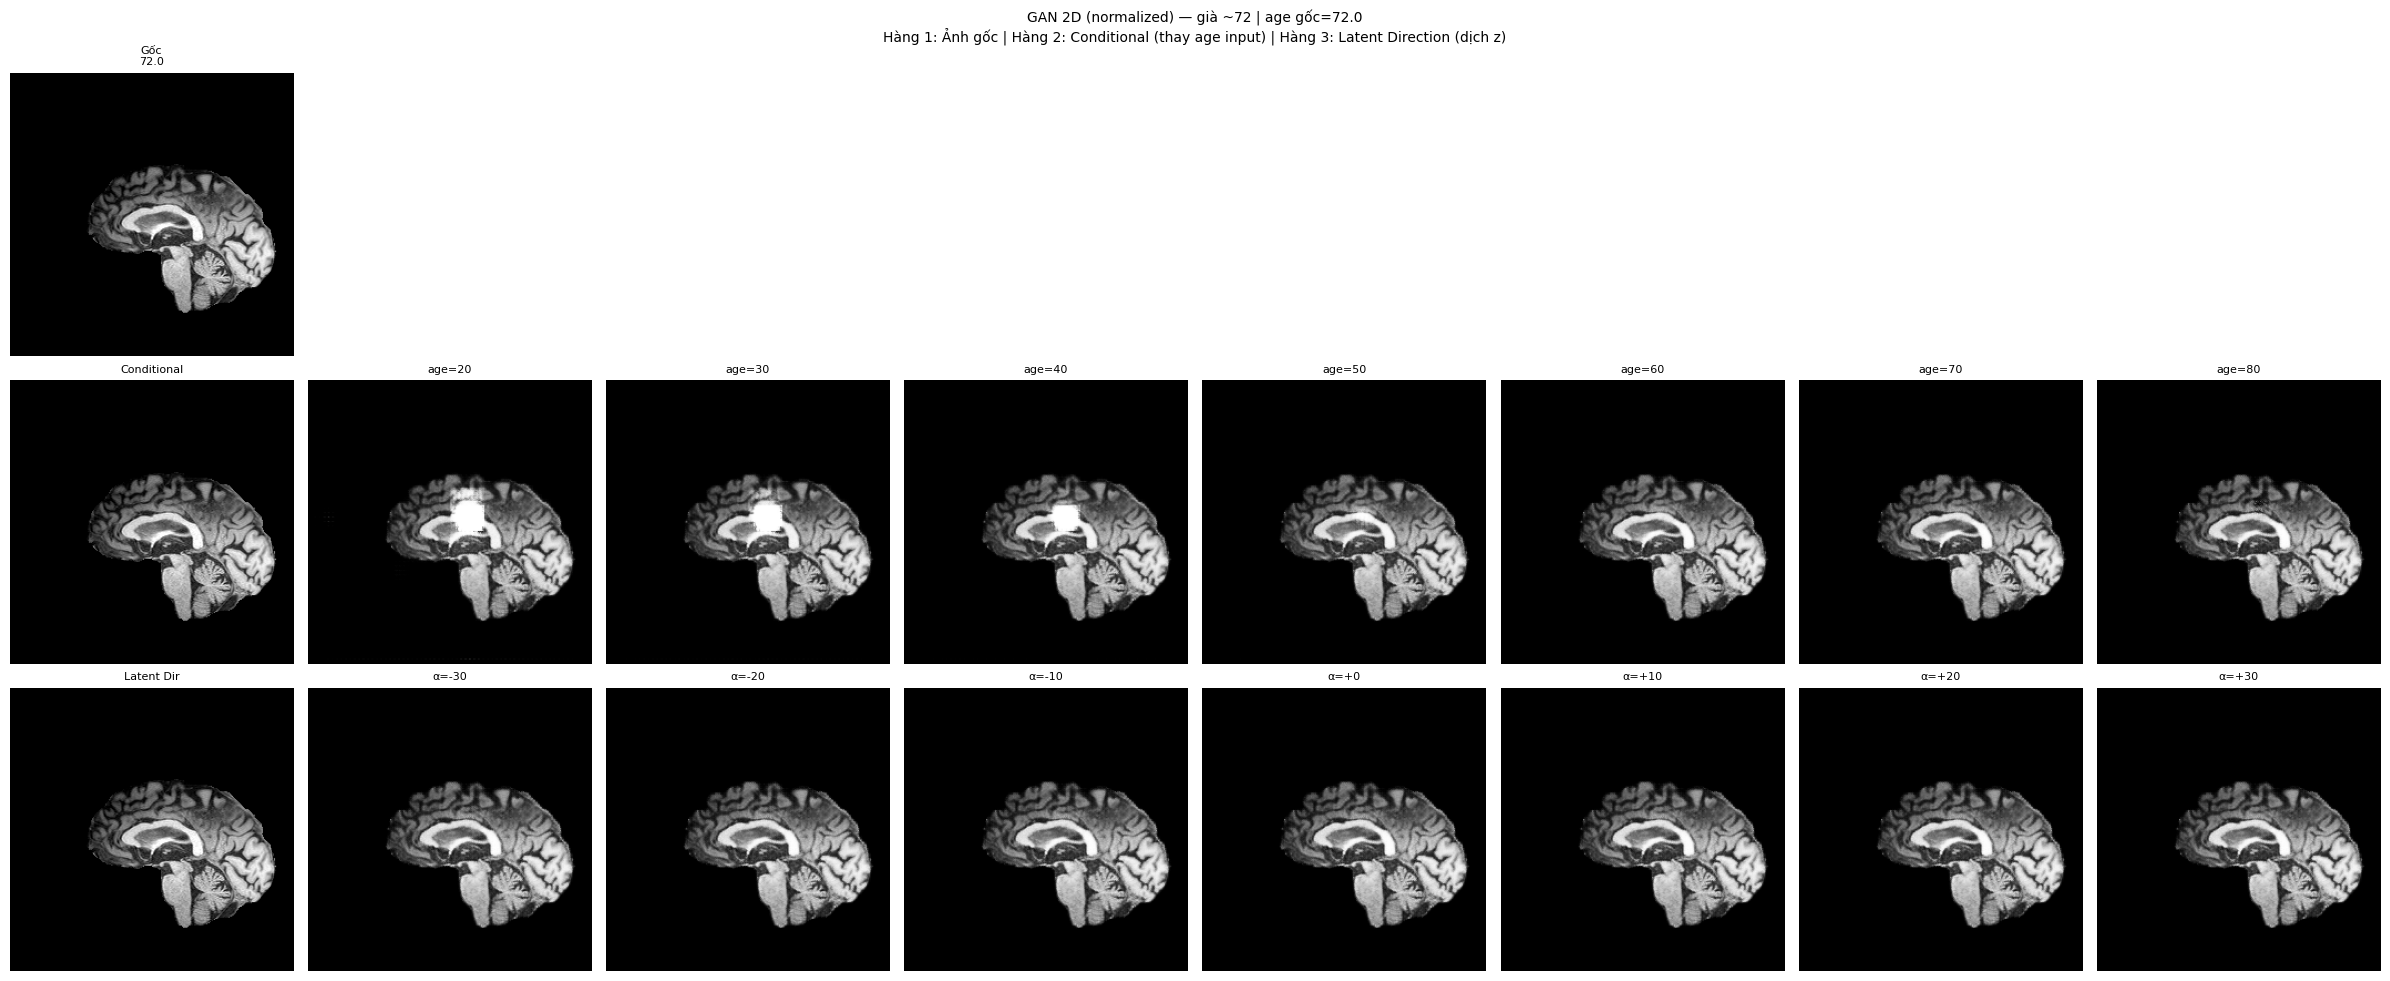

già ~72 (age=72.0) xong!
GAN 2D latent manipulation xong!


In [7]:
# ── Bước 5A: Tìm Age Direction Vector trong Latent Space 2D ──
# Thu thập z của nhiều subject → fit linear regression z ~ age
# → direction vector = hướng 'già hơn' trong latent space
from sklearn.linear_model import LinearRegression
import torchvision.transforms as transforms

df_2d = pd.read_csv(LABELS_2D_CSV)
df_2d['full_path'] = df_2d['png_file'].apply(lambda x: os.path.join(DATA_2D_DIR, x))
df_2d = df_2d[df_2d['full_path'].apply(os.path.exists)].reset_index(drop=True)
df_sample = df_2d.sample(n=min(N_SAMPLES, len(df_2d)), random_state=42)

transform = transforms.Compose([
    transforms.Resize((256,256)), transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

def normalize_age_2d(age):
    return 2*(age-ckpt_2d['age_min'])/(ckpt_2d['age_max']-ckpt_2d['age_min'])-1

print('Đang extract z 2D để tìm age direction...')
all_z, all_ages = [], []
G2D.eval()
with torch.no_grad():
    for _, row in df_sample.iterrows():
        img = transform(Image.open(row['full_path']).convert('L')).unsqueeze(0).to(DEVICE)
        age_t = torch.tensor([normalize_age_2d(row['age'])], dtype=torch.float32).to(DEVICE)
        z = G2D.encode(img, age_t)  # (1, 512)
        all_z.append(z.cpu().numpy())
        all_ages.append(row['age'])

Z_2d   = np.vstack(all_z)      # (N, 512)
ages_2d = np.array(all_ages)   # (N,)

# Fit linear regression: z = age * w + b → w là direction vector
reg = LinearRegression().fit(ages_2d.reshape(-1,1), Z_2d)
age_direction_2d = reg.coef_[0]                          # (512,)
age_direction_2d = age_direction_2d / np.linalg.norm(age_direction_2d)  # normalize
print(f'Age direction 2D found! norm={np.linalg.norm(reg.coef_[0]):.4f}')

# ── Bước 5B: Chọn 3 subject đại diện (trẻ / trung niên / già) ─
subjects_2d = []
for age_target, label in [(22, 'trẻ ~22'), (50, 'trung niên ~50'), (72, 'già ~72')]:
    idx = (df_2d['age'] - age_target).abs().idxmin()
    subjects_2d.append((df_2d.loc[idx, 'full_path'], df_2d.loc[idx, 'age'], label))

# ── Bước 5C: Với mỗi subject — so sánh 2 cách manipulation ────
ALPHA_RANGE = np.linspace(-30, 30, len(TARGET_AGES))  # bước dịch chuyển z

for png_path, age_orig, label in subjects_2d:
    sample_2d = transform(Image.open(png_path).convert('L')).unsqueeze(0).to(DEVICE)
    orig_np   = (sample_2d[0,0].cpu().numpy() + 1) / 2

    G2D.eval()
    with torch.no_grad():
        age_t_orig = torch.tensor([normalize_age_2d(age_orig)], dtype=torch.float32).to(DEVICE)
        z_orig = G2D.encode(sample_2d, age_t_orig)  # (1, 512)

    # Cách 1: Conditional — thay đổi age input
    cond_imgs = []
    with torch.no_grad():
        for ta in TARGET_AGES:
            age_t = torch.tensor([normalize_age_2d(ta)], dtype=torch.float32).to(DEVICE)
            fake  = G2D(sample_2d, age_t)
            cond_imgs.append((fake[0,0].cpu().numpy() + 1) / 2)

    # Cách 2: Latent direction — dịch chuyển z
    direction_t = torch.tensor(age_direction_2d, dtype=torch.float32).to(DEVICE)
    dir_imgs = []
    with torch.no_grad():
        for alpha in ALPHA_RANGE:
            z_shifted = z_orig + alpha * direction_t  # (1, 512)
            # Decode: dùng decoder của G2D với z đã dịch
            z_s = z_shifted.view(-1, 512, 1, 1)
            d1 = G2D.d1(z_s)
            # Cần skip connections — lấy từ encode lần nữa
            e1=G2D.e1(sample_2d); e2=G2D.e2(e1); e3=G2D.e3(e2); e4=G2D.e4(e3)
            e5=G2D.e5(e4); e6=G2D.e6(e5); e7=G2D.e7(e6)
            d1=G2D.d1(z_s); d2=G2D.d2(torch.cat([d1,e7],1))
            d3=G2D.d3(torch.cat([d2,e6],1)); d4=G2D.d4(torch.cat([d3,e5],1))
            d5=G2D.d5(torch.cat([d4,e4],1)); d6=G2D.d6(torch.cat([d5,e3],1))
            d7=G2D.d7(torch.cat([d6,e2],1))
            out = G2D.out(torch.cat([d7,e1],1))
            dir_imgs.append((out[0,0].cpu().numpy() + 1) / 2)

    # ── Vẽ so sánh 2 cách ────────────────────────────────────
    n = len(TARGET_AGES)
    fig, axes = plt.subplots(3, n+1, figsize=(3*(n+1), 10))
    fig.suptitle(f'GAN 2D ({winner_2d}) — {label} | age gốc={age_orig:.1f}\n'
                 f'Hàng 1: Ảnh gốc | Hàng 2: Conditional (thay age input) | '
                 f'Hàng 3: Latent Direction (dịch z)', fontsize=10)

    # Hàng 1: ảnh gốc
    axes[0][0].imshow(orig_np, cmap='gray')
    axes[0][0].set_title(f'Gốc\n{age_orig:.1f}', fontsize=8); axes[0][0].axis('off')
    for j in range(1, n+1): axes[0][j].axis('off')

    # Hàng 2: conditional
    axes[1][0].imshow(orig_np, cmap='gray')
    axes[1][0].set_title('Conditional', fontsize=8); axes[1][0].axis('off')
    for j, (ta, img) in enumerate(zip(TARGET_AGES, cond_imgs)):
        axes[1][j+1].imshow(img, cmap='gray')
        axes[1][j+1].set_title(f'age={ta}', fontsize=8); axes[1][j+1].axis('off')

    # Hàng 3: latent direction
    axes[2][0].imshow(orig_np, cmap='gray')
    axes[2][0].set_title('Latent Dir', fontsize=8); axes[2][0].axis('off')
    for j, (alpha, img) in enumerate(zip(ALPHA_RANGE, dir_imgs)):
        axes[2][j+1].imshow(img, cmap='gray')
        axes[2][j+1].set_title(f'α={alpha:+.0f}', fontsize=8); axes[2][j+1].axis('off')

    plt.tight_layout()
    safe_label = label.replace(' ', '_').replace('/', '_').replace('~', '')
    plt.savefig(f'{OUTPUT_DIR}/2d_manipulation_{safe_label}.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'{label} (age={age_orig:.1f}) xong!')

print('GAN 2D latent manipulation xong!')


## Bước 6: Latent Manipulation — GAN 3D

Đang extract z 3D để tìm age direction...
Age direction 3D found!


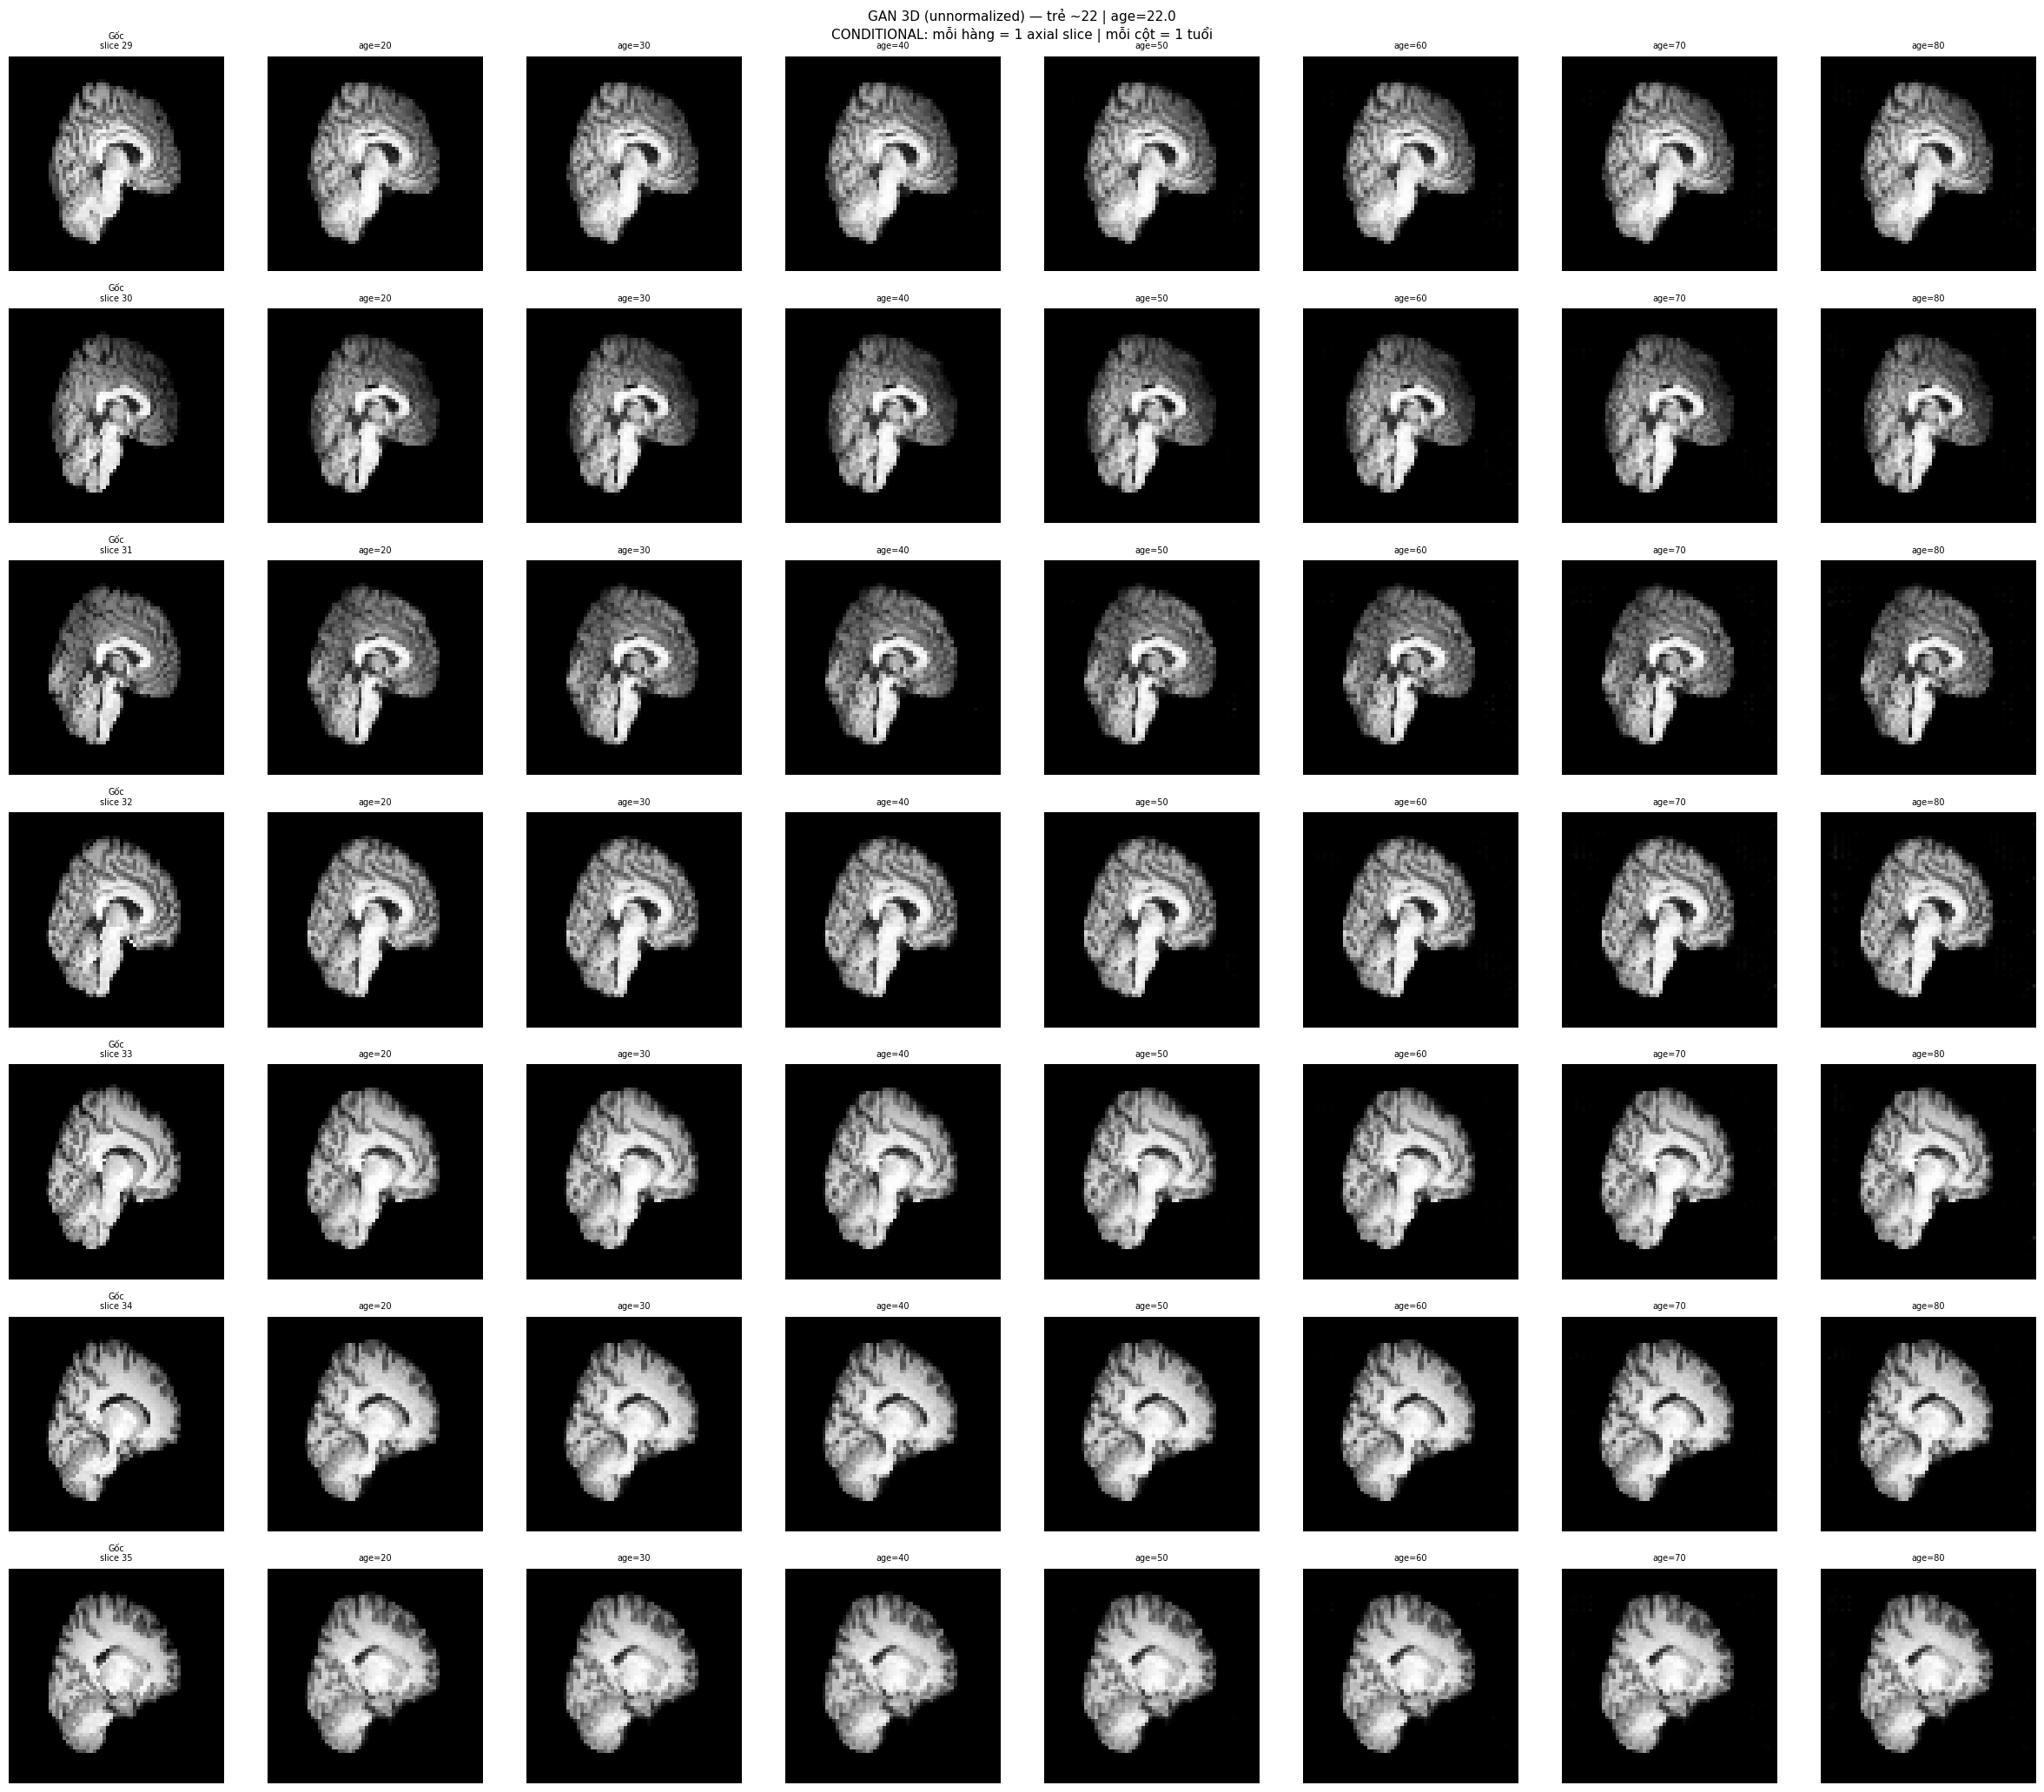

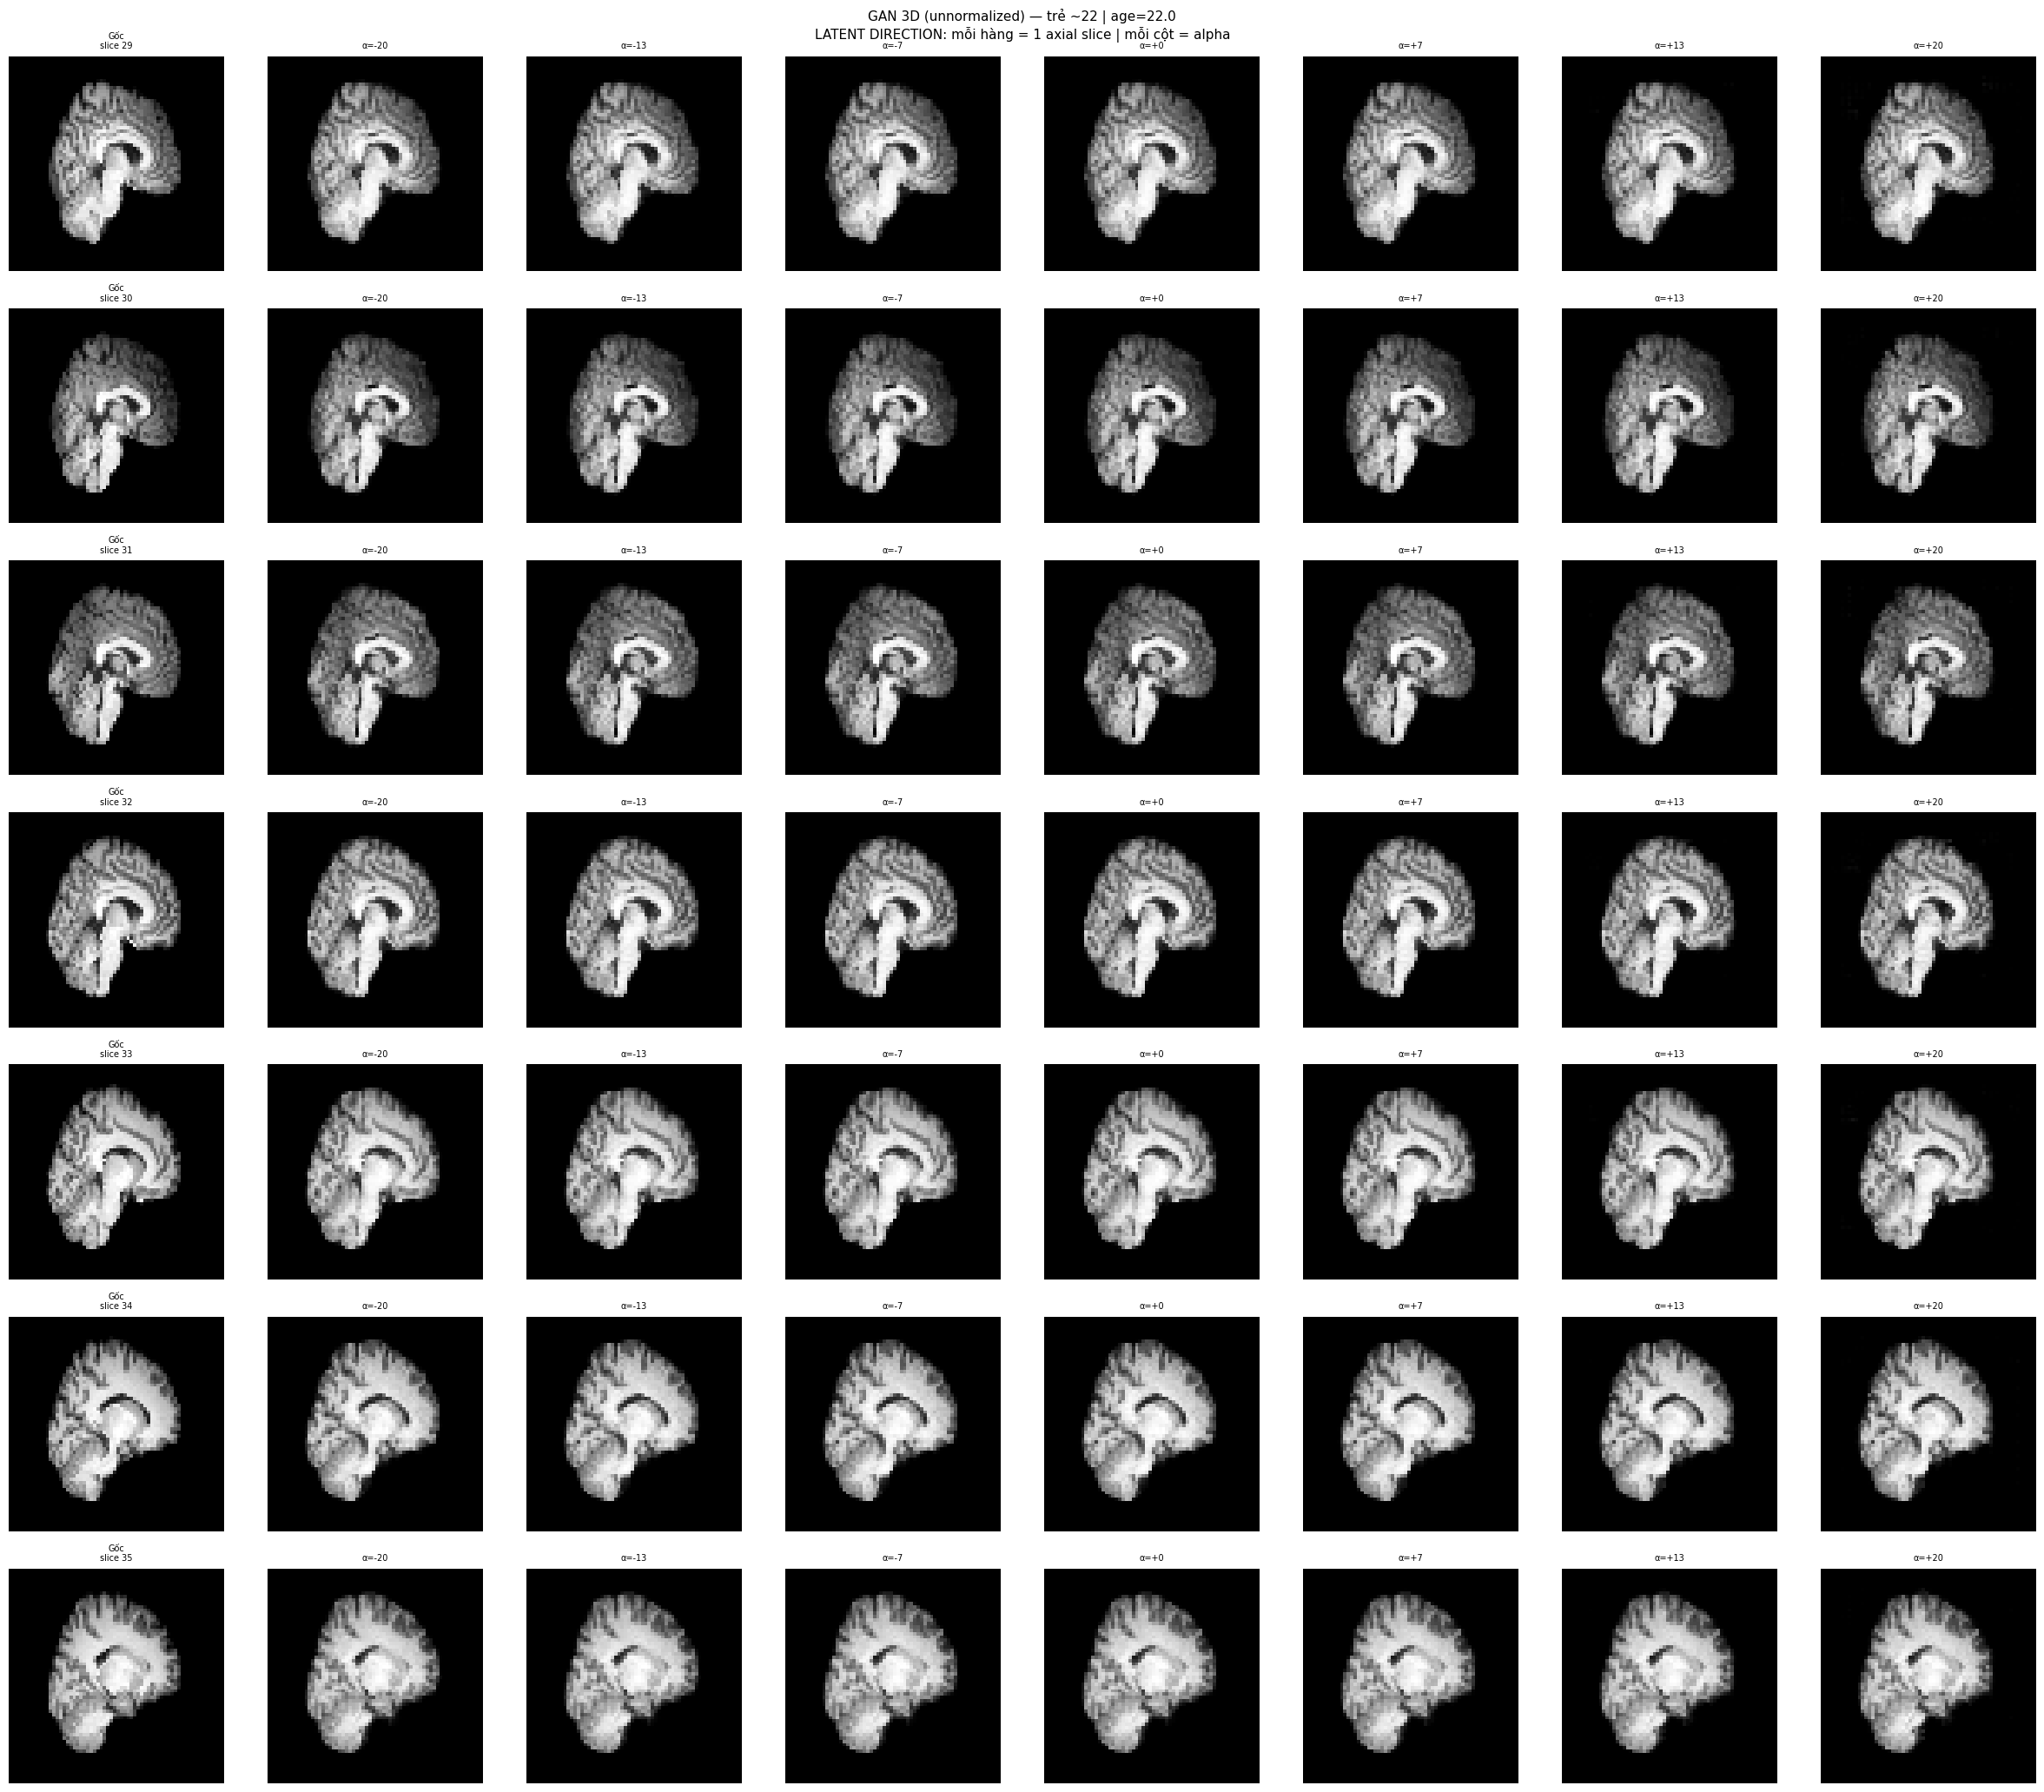

trẻ ~22 (age=22.0) xong!


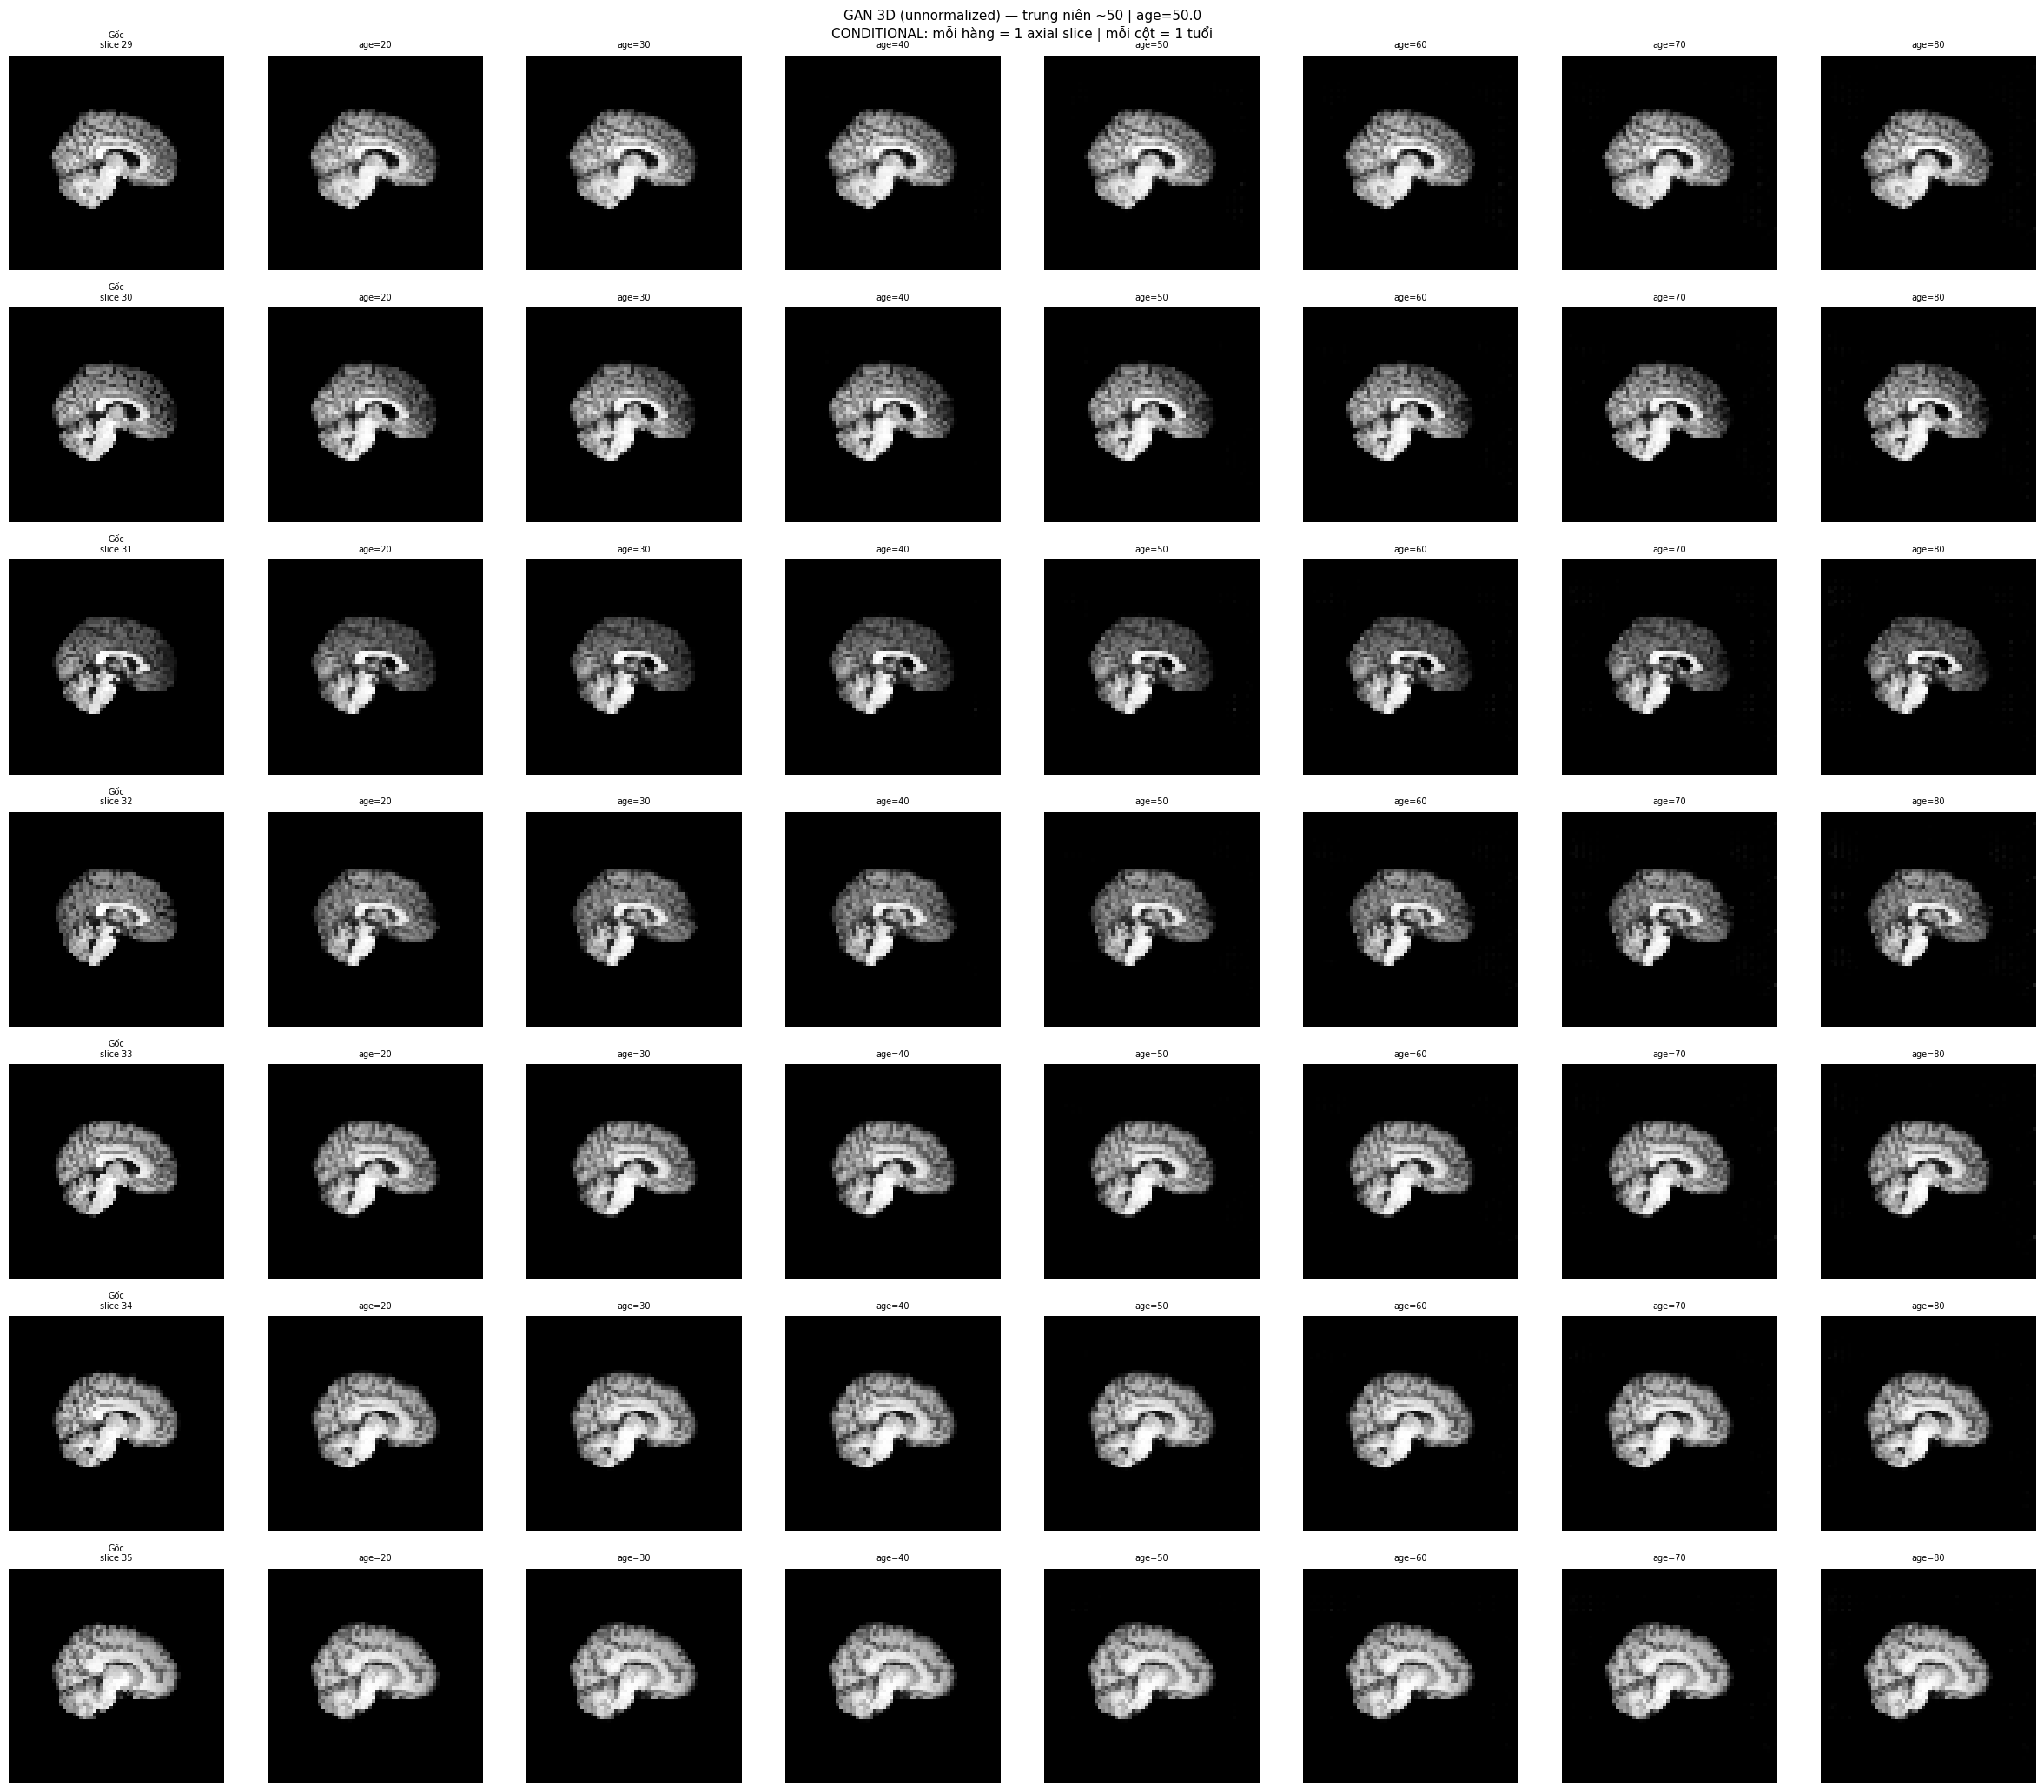

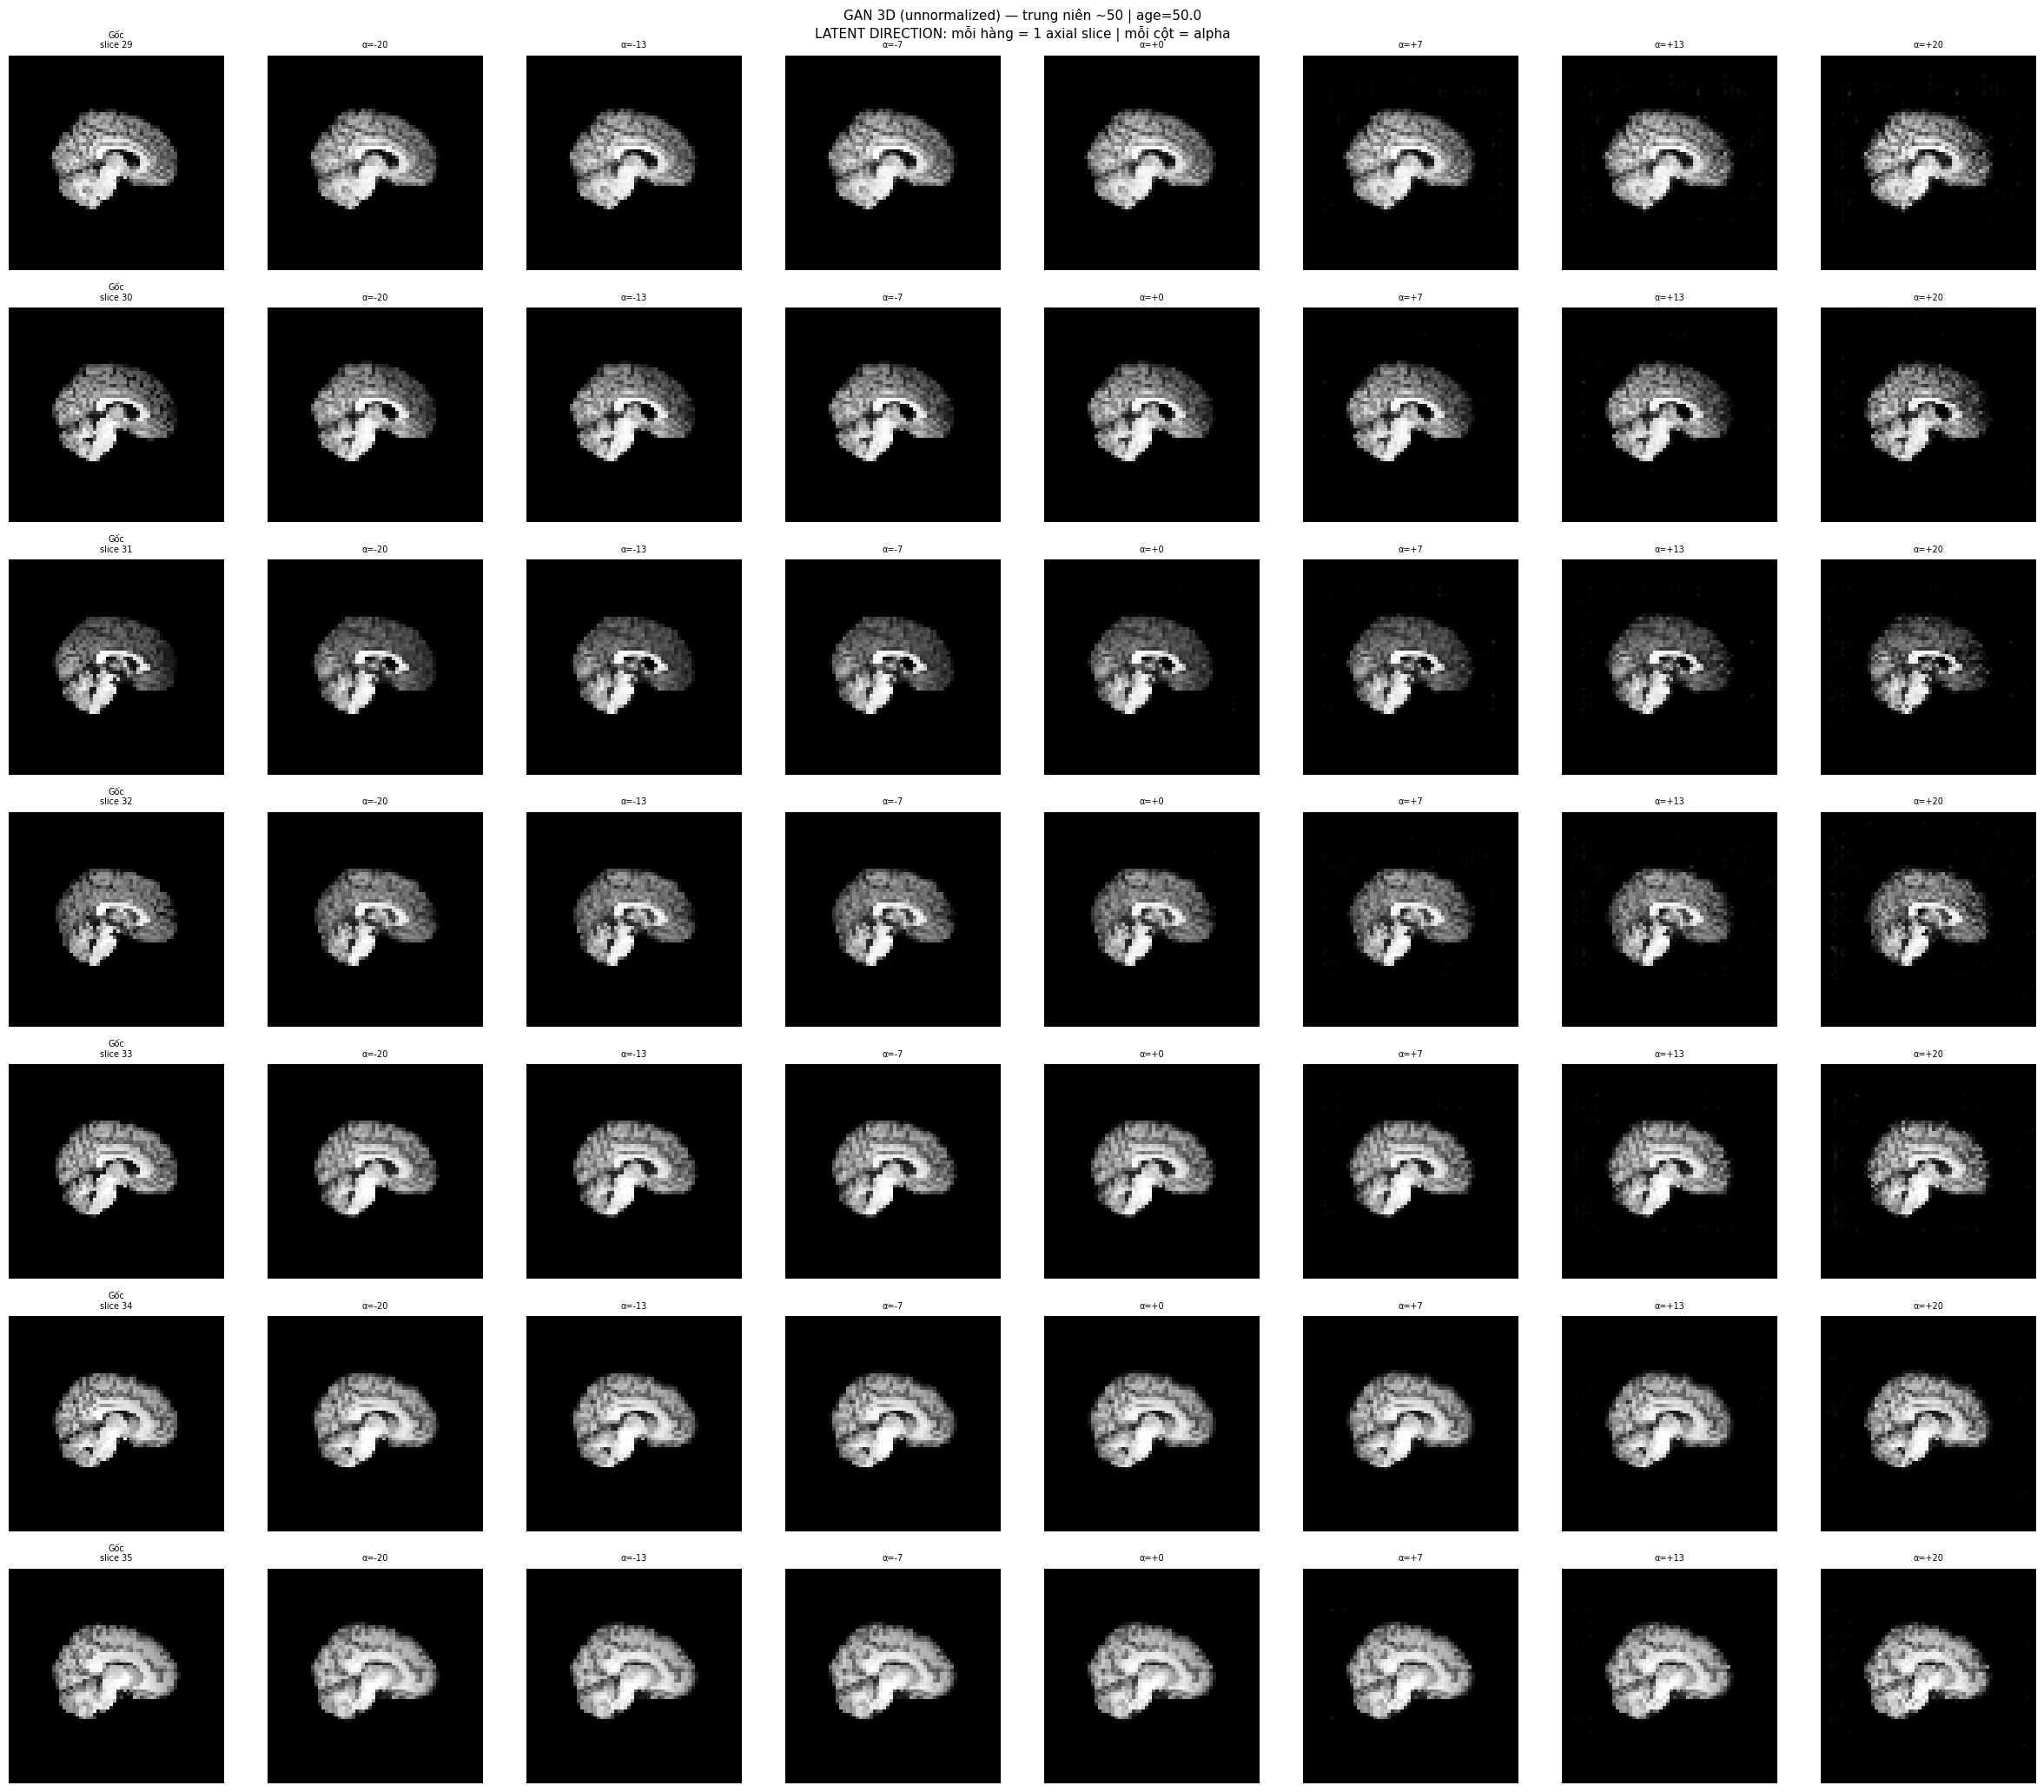

trung niên ~50 (age=50.0) xong!


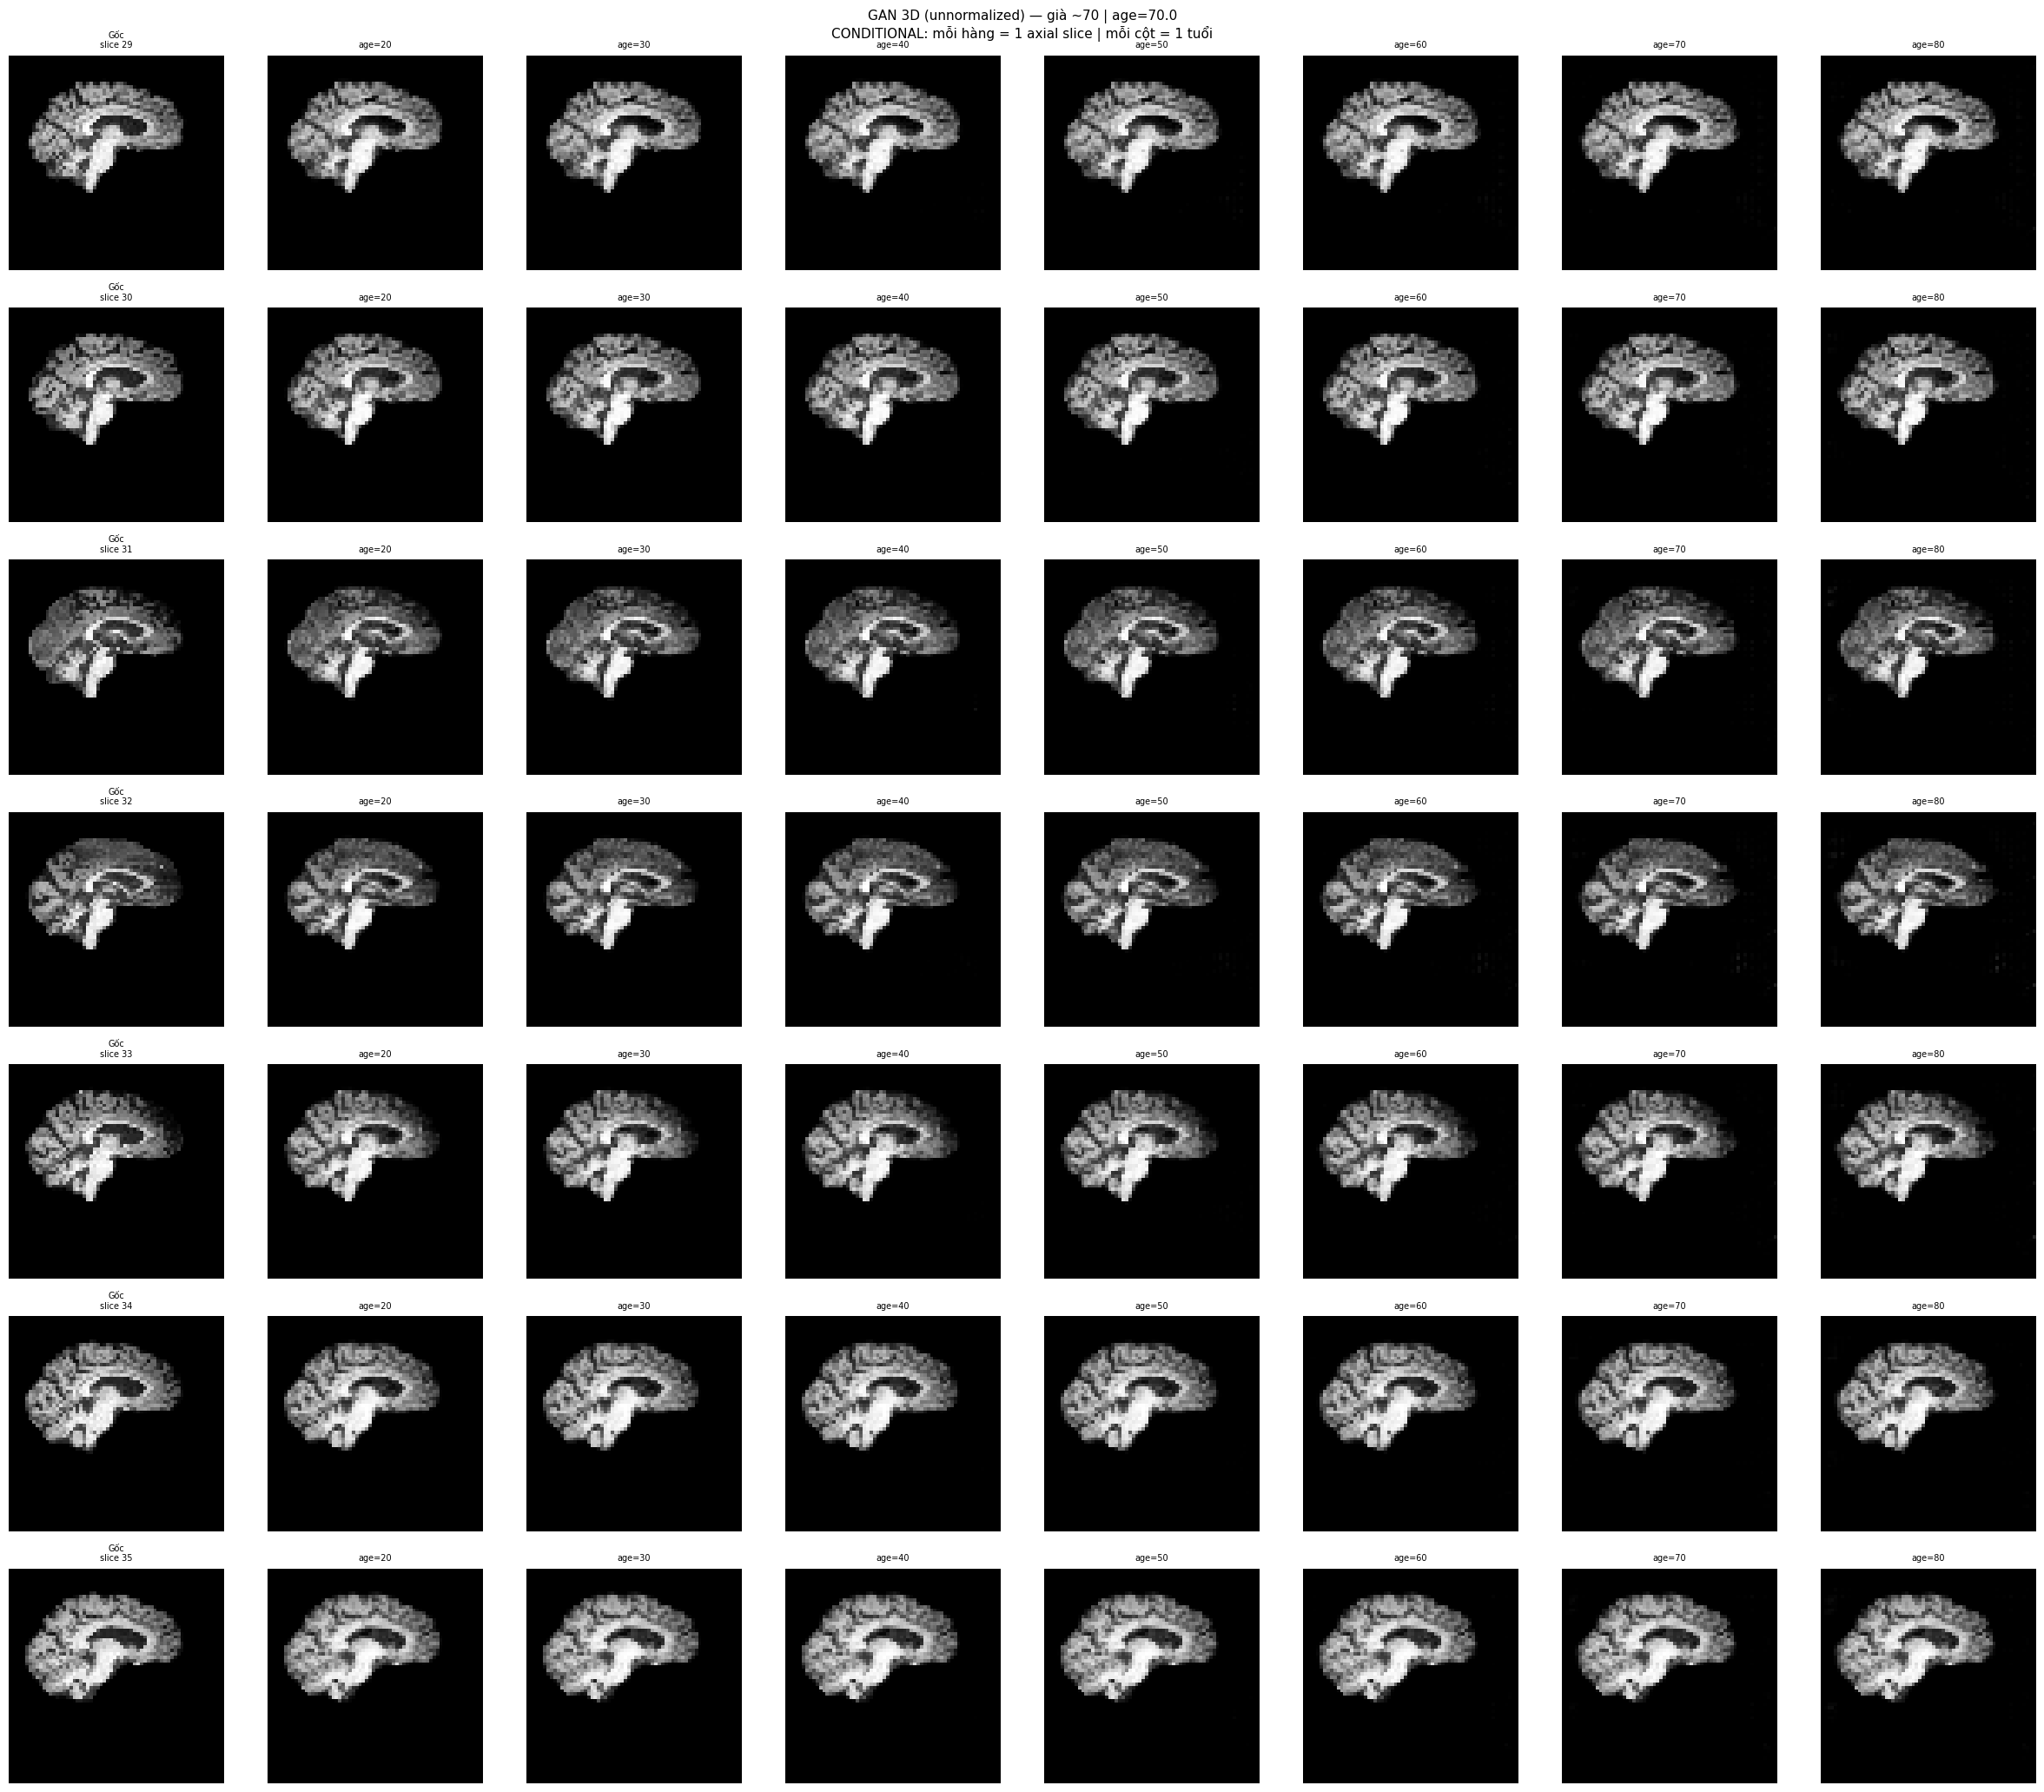

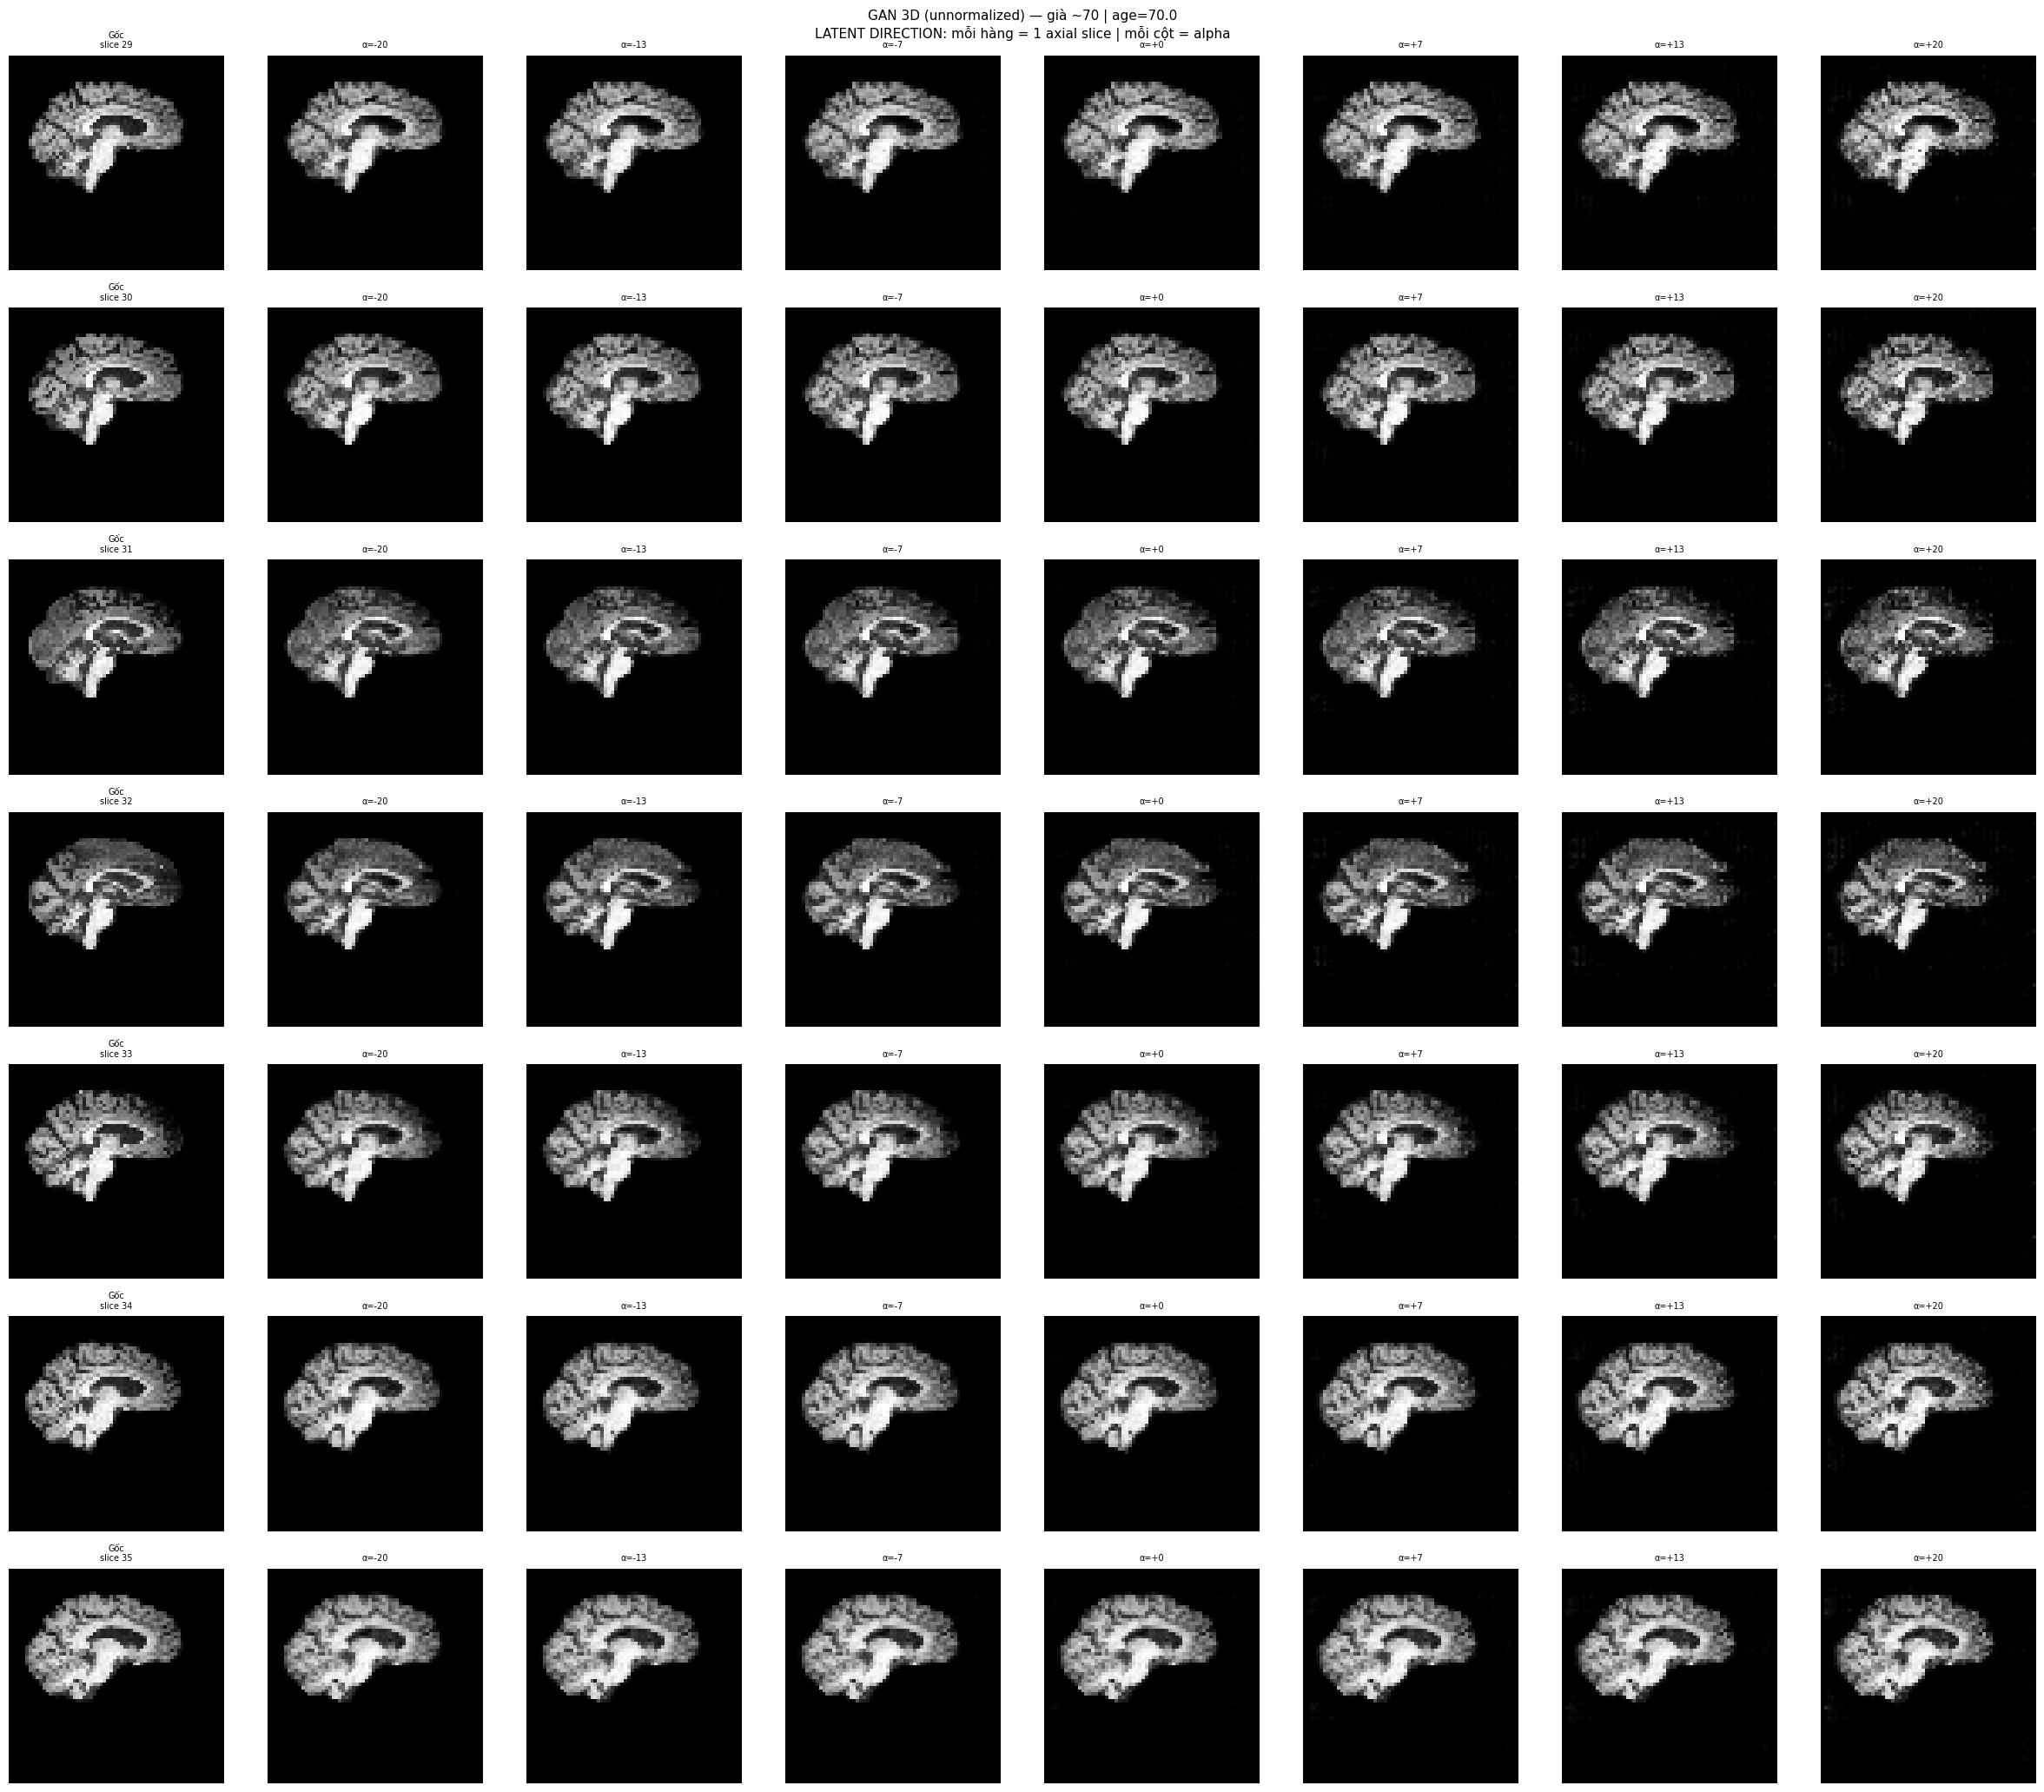

già ~70 (age=70.0) xong!
GAN 3D latent manipulation xong!


In [8]:
# ── Bước 6A: Tìm Age Direction Vector trong Latent Space 3D ──
df_3d = pd.read_csv(LABELS_3D_CSV)
volume_size = ckpt_3d.get('volume_size', 64)

def find_nii(data_dir, subject_id):
    for ext in ['.nii.gz', '.nii']:
        p = os.path.join(data_dir, f'{subject_id}{ext}')
        if os.path.exists(p): return p
    return None

def normalize_age_3d(age):
    return 2*(age-ckpt_3d['age_min'])/(ckpt_3d['age_max']-ckpt_3d['age_min'])-1

def load_vol(nii_path):
    data = nib.load(nii_path).get_fdata().astype(np.float32)
    vol  = torch.tensor(data).unsqueeze(0).unsqueeze(0)
    vol  = F.interpolate(vol, size=(volume_size,)*3, mode='trilinear', align_corners=False)
    return (vol.squeeze(0)*2-1).unsqueeze(0)

print('Đang extract z 3D để tìm age direction...')
df_3d['nii_path'] = df_3d['subject_id'].apply(lambda x: find_nii(DATA_3D_DIR, x))
df_3d_valid = df_3d[df_3d['nii_path'].notna()].reset_index(drop=True)
df_3d_sample = df_3d_valid.sample(n=min(100, len(df_3d_valid)), random_state=42)

all_z3, all_ages3 = [], []
G3D.eval()
with torch.no_grad():
    for _, row in df_3d_sample.iterrows():
        vol   = load_vol(row['nii_path']).to(DEVICE)
        age_t = torch.tensor([normalize_age_3d(row['age'])], dtype=torch.float32).to(DEVICE)
        z     = G3D.encode(vol, age_t)  # (1, 256)
        all_z3.append(z.cpu().numpy())
        all_ages3.append(row['age'])

Z_3d    = np.vstack(all_z3)
ages_3d = np.array(all_ages3)
reg3    = LinearRegression().fit(ages_3d.reshape(-1,1), Z_3d)
age_direction_3d = reg3.coef_[0]
age_direction_3d = age_direction_3d / np.linalg.norm(age_direction_3d)
print(f'Age direction 3D found!')

# ── Bước 6B: Chọn 3 subject đại diện ─────────────────────────
subjects_3d = []
for age_target, label in [(22, 'trẻ ~22'), (50, 'trung niên ~50'), (70, 'già ~70')]:
    idx = (df_3d_valid['age'] - age_target).abs().idxmin()
    subjects_3d.append((df_3d_valid.loc[idx, 'nii_path'],
                        df_3d_valid.loc[idx, 'age'], label))

# Các slice axial muốn hiển thị (giống ảnh trong paper)
SLICE_OFFSETS = [-3, -2, -1, 0, 1, 2, 3]  # offset từ giữa
ALPHA_RANGE   = np.linspace(-20, 20, len(TARGET_AGES))

for nii_path, age_orig, label in subjects_3d:
    sample_3d = load_vol(nii_path).to(DEVICE)
    mid       = volume_size // 2

    G3D.eval()
    with torch.no_grad():
        age_t_orig = torch.tensor([normalize_age_3d(age_orig)], dtype=torch.float32).to(DEVICE)
        z_orig = G3D.encode(sample_3d, age_t_orig)  # (1, 256)

    # Cách 1: Conditional
    cond_slices = []  # list of (n_slices,) arrays
    with torch.no_grad():
        for ta in TARGET_AGES:
            age_t = torch.tensor([normalize_age_3d(ta)], dtype=torch.float32).to(DEVICE)
            fake  = G3D(sample_3d, age_t)
            fake_np = (fake[0,0].cpu().numpy() + 1) / 2
            cond_slices.append([fake_np[mid+off,:,:] for off in SLICE_OFFSETS])

    # Cách 2: Latent direction
    dir_slices = []
    direction_t3 = torch.tensor(age_direction_3d, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        for alpha in ALPHA_RANGE:
            z_shifted = z_orig + alpha * direction_t3
            # Encode để lấy skip connections và spatial size của e4
            e1=G3D.e1(sample_3d); e2=G3D.e2(e1)
            e3=G3D.e3(e2);        e4=G3D.e4(e3)
            # Expand z_shifted về đúng spatial size của e4
            sp = e4.shape[2:]  # (S, S, S)
            z_s = z_shifted.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1).expand(-1, -1, *sp)
            d1=G3D.d1(z_s); d2=G3D.d2(torch.cat([d1,e3],1))
            d3=G3D.d3(torch.cat([d2,e2],1))
            out = G3D.out(torch.cat([d3,e1],1))
            fake_np = (out[0,0].cpu().numpy() + 1) / 2
            dir_slices.append([fake_np[mid+off,:,:] for off in SLICE_OFFSETS])

    orig_vol = (sample_3d[0,0].cpu().numpy() + 1) / 2
    n_sl = len(SLICE_OFFSETS)
    n_ag = len(TARGET_AGES)

    # ── Vẽ Conditional: rows=slices, cols=ages ────────────────
    fig, axes = plt.subplots(n_sl, n_ag+1, figsize=(3*(n_ag+1), 3*n_sl))
    fig.suptitle(f'GAN 3D ({winner_3d}) — {label} | age={age_orig:.1f}\n'
                 f'CONDITIONAL: mỗi hàng = 1 axial slice | mỗi cột = 1 tuổi', fontsize=11)
    for si, off in enumerate(SLICE_OFFSETS):
        sl_idx = mid + off
        axes[si][0].imshow(orig_vol[sl_idx,:,:].T, cmap='gray', origin='lower')
        axes[si][0].set_title(f'Gốc\nslice {sl_idx}', fontsize=7); axes[si][0].axis('off')
        for ai, ta in enumerate(TARGET_AGES):
            axes[si][ai+1].imshow(cond_slices[ai][si].T, cmap='gray', origin='lower')
            axes[si][ai+1].set_title(f'age={ta}', fontsize=7); axes[si][ai+1].axis('off')
    plt.tight_layout()
    safe = label.replace(' ','_').replace('/','_').replace('~','')
    plt.savefig(f'{OUTPUT_DIR}/3d_cond_{safe}.png', dpi=80, bbox_inches='tight')
    plt.show()

    # ── Vẽ Latent Direction: rows=slices, cols=alpha ──────────
    fig, axes = plt.subplots(n_sl, n_ag+1, figsize=(3*(n_ag+1), 3*n_sl))
    fig.suptitle(f'GAN 3D ({winner_3d}) — {label} | age={age_orig:.1f}\n'
                 f'LATENT DIRECTION: mỗi hàng = 1 axial slice | mỗi cột = alpha', fontsize=11)
    for si, off in enumerate(SLICE_OFFSETS):
        sl_idx = mid + off
        axes[si][0].imshow(orig_vol[sl_idx,:,:].T, cmap='gray', origin='lower')
        axes[si][0].set_title(f'Gốc\nslice {sl_idx}', fontsize=7); axes[si][0].axis('off')
        for ai, alpha in enumerate(ALPHA_RANGE):
            axes[si][ai+1].imshow(dir_slices[ai][si].T, cmap='gray', origin='lower')
            axes[si][ai+1].set_title(f'α={alpha:+.0f}', fontsize=7); axes[si][ai+1].axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/3d_latentdir_{safe}.png', dpi=80, bbox_inches='tight')
    plt.show()
    print(f'{label} (age={age_orig:.1f}) xong!')

print('GAN 3D latent manipulation xong!')
